# Strava Fitness Data Analytics Case Study
### How Can a Wellness Technology Company Play It Smart?

This notebook develops an end-to-end fitness analytics workflow using public smart-device fitness tracker data as a proxy for consumer wellness behavior.

The analysis progresses from **raw multi-source data** to a validated daily master dataset, followed by:

- Exploratory Data Analysis (EDA)
- Statistical analysis and hypothesis testing
- Predictive modeling
- Business and behavioral interpretation

The overall objective is to identify measurable patterns in **activity, calorie expenditure, sedentary behavior, sleep, heart rate, and engagement** that can support wellness-product and marketing analysis.

> **Scope:** The analysis is observational and is intended to identify behavioral patterns and associations. It is not a clinical or medical assessment.

## Project Summary

The project combines activity, sleep, heart-rate, and weight-related source files into a single analytical workflow.

The raw data contains multiple time granularities, including daily, hourly, minute-level, and high-frequency heart-rate observations. These sources are standardized and aggregated to a common **participant + date** grain before analysis.

The resulting master dataset is used to:

1. Assess data quality and coverage.
2. Explore daily activity and wellness behavior.
3. Quantify relationships using statistical methods.
4. Evaluate whether activity measures can predict daily calorie expenditure.
5. Translate the findings into business and behavioral insights.

The cleaned dataset also serves as the foundation for downstream SQL analysis and dashboard development.


## Problem Statement

The business objective is to understand how consumers use smart fitness devices and identify behavioral patterns that may inform wellness-product and marketing strategy.

The raw dataset presents several analytical challenges:

- Data is distributed across **15 source files**.
- The files use different time granularities and date formats.
- Activity, sleep, heart-rate, and other measures are stored separately.
- Duplicate participant-date records and missing values require validation.
- There is no single daily source of truth connecting the major behavioral measures.

The core analytical question is:

> **What patterns can be identified in smart-device usage behavior, and how can those patterns be translated into useful business insights?**

This notebook addresses that question by building a consistent daily analytical dataset and applying descriptive, statistical, and predictive methods.


## Background & Business Task

### Background

The case study uses public smart-device fitness tracker data to examine how users interact with wellness technology across activity, sleep, and related behavioral measures.

### Business Task

The analysis is designed to understand:

- How active participants are on a daily basis.
- How activity relates to calorie expenditure.
- How much time participants spend active versus sedentary.
- How sleep behavior relates to daily activity.
- Whether activity patterns differ across weekdays and weekends.
- Whether activity variables provide useful predictive information for calorie expenditure.

### Stakeholders

- **Business leadership / marketing stakeholders** — interested in consumer behavior and engagement patterns.
- **Marketing analytics teams** — responsible for translating behavioral data into measurable insights and recommendations.

### Deliverables

This notebook provides:

1. Data preparation and quality validation.
2. Exploratory analysis and visualizations.
3. Statistical testing and effect-size analysis.
4. Machine-learning model comparison.
5. Business and behavioral findings.
6. A final analytical conclusion.

### Analysis Principle

The project distinguishes between **observed associations**, **statistical differences**, and **predictive relationships**. None of these should automatically be interpreted as causal effects.


In [127]:
# Imports
import pandas as pd
import numpy as np
from pathlib import Path
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Define paths
DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../data/processed")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Input directory:", DATA_DIR.resolve())
print("Output directory:", OUTPUT_DIR.resolve())

Input directory: D:\Strava Fitness App Project\data
Output directory: D:\Strava Fitness App Project\data\processed


In [3]:
# Load all datasets
files = {
    "daily_activity": "dailyActivity_merged.csv",
    "daily_calories": "dailyCalories_merged.csv",
    "daily_intensities": "dailyIntensities_merged.csv",
    "daily_steps": "dailySteps_merged.csv",
    "heart_rate": "heartrate_seconds_merged.csv",
    "hourly_calories": "hourlyCalories_merged.csv",
    "hourly_intensities": "hourlyIntensities_merged.csv",
    "hourly_steps": "hourlySteps_merged.csv",
    "minute_calories": "minuteCaloriesNarrow_merged.csv",
    "minute_intensities": "minuteIntensitiesNarrow_merged.csv",
    "minute_mets": "minuteMETsNarrow_merged.csv",
    "minute_steps": "minuteStepsNarrow_merged.csv",
    "sleep_day": "sleepDay_merged.csv",
    "minute_sleep": "minuteSleep_merged.csv",
    "weight": "weightLogInfo_merged.csv"
}

data = {
    name: pd.read_csv(DATA_DIR / filename)
    for name, filename in files.items()
}

print(f"Loaded {len(data)} datasets.")

Loaded 15 datasets.


In [4]:
# Dataset overview
overview = pd.DataFrame({
    "Dataset": data.keys(),
    "Rows": [df.shape[0] for df in data.values()],
    "Columns": [df.shape[1] for df in data.values()],
    "Missing Values": [df.isna().sum().sum() for df in data.values()],
    "Duplicate Rows": [df.duplicated().sum() for df in data.values()]
})

overview

,Dataset,Rows,Columns,Missing Values,Duplicate Rows
0,daily_activity,940,15,0,0
1,daily_calories,940,3,0,0
2,daily_intensities,940,10,0,0
3,daily_steps,940,3,0,0
4,heart_rate,2483658,3,0,0
5,hourly_calories,22099,3,0,0
6,hourly_intensities,22099,4,0,0
7,hourly_steps,22099,3,0,0
8,minute_calories,1325580,3,0,0
9,minute_intensities,1325580,3,0,0


In [5]:
# Inspect columns
for name, df in data.items():
    print(f"\n{name.upper()}")
    print("-" * len(name))
    print(df.columns.tolist())


DAILY_ACTIVITY
--------------
['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance', 'LoggedActivitiesDistance', 'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories']

DAILY_CALORIES
--------------
['Id', 'ActivityDay', 'Calories']

DAILY_INTENSITIES
-----------------
['Id', 'ActivityDay', 'SedentaryMinutes', 'LightlyActiveMinutes', 'FairlyActiveMinutes', 'VeryActiveMinutes', 'SedentaryActiveDistance', 'LightActiveDistance', 'ModeratelyActiveDistance', 'VeryActiveDistance']

DAILY_STEPS
-----------
['Id', 'ActivityDay', 'StepTotal']

HEART_RATE
----------
['Id', 'Time', 'Value']

HOURLY_CALORIES
---------------
['Id', 'ActivityHour', 'Calories']

HOURLY_INTENSITIES
------------------
['Id', 'ActivityHour', 'TotalIntensity', 'AverageIntensity']

HOURLY_STEPS
------------
['Id', 'ActivityHour', 'StepTotal']

MINUTE_CALORIES
-

## Data Cleaning & Integration

The raw source files are transformed into a consistent daily analytical dataset.

### Cleaning and Integration Steps

- Standardize participant IDs and date fields.
- Remove duplicate participant-date records where required.
- Convert numeric fields to appropriate numeric data types.
- Aggregate hourly and minute-level activity measures to the daily level.
- Aggregate heart-rate observations into daily summary statistics.
- Prepare sleep and weight data for participant-date analysis.
- Merge compatible sources using `Id` + `Date`.
- Engineer behavioral features such as day of week, weekend status, activity minutes, and goal indicators.
- Validate the final dataset for missing IDs/dates and duplicate participant-date records.

### Derived Features

The master dataset includes analytical fields such as:

- `Day_Of_Week`
- `Day_Of_Week_Num`
- `Is_Weekend`
- `Month`
- `Week`
- `Total_Active_Minutes`
- `Meets_10k_Steps`
- `Sleep_7h_Target`
- `Sleep_Efficiency_Pct`

### Output Artifacts

The cleaning pipeline produces:

- `fitness_daily_master.csv`
- `fitness_data_dictionary.csv`

The objective is to establish a reproducible **participant + date** analytical layer before performing EDA or modeling.


In [6]:
# Create cleaning helper
def clean_id_date(df, date_column):
    df = df.copy()

    df["Id"] = pd.to_numeric(
        df["Id"],
        errors="coerce"
    ).astype("Int64")

    df["Date"] = pd.to_datetime(
        df[date_column],
        errors="coerce"
    ).dt.normalize()

    return df.drop(
        columns=[date_column],
        errors="ignore"
    )

In [7]:
# Clean daily activity
daily = clean_id_date(
    data["daily_activity"],
    "ActivityDate"
)

daily = daily.drop_duplicates(
    subset=["Id", "Date"]
)

numeric_columns = daily.select_dtypes(
    include=np.number
).columns

daily[numeric_columns] = daily[numeric_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

print("Daily activity shape:", daily.shape)
daily.head()

Daily activity shape: (940, 15)


,Id,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,Date
0,1503960366,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,2016-04-12
1,1503960366,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,2016-04-13
2,1503960366,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776,2016-04-14
3,1503960366,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,2016-04-15
4,1503960366,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,2016-04-16


In [8]:
# Validate daily activity
print("Participants:", daily["Id"].nunique())
print("Date range:", daily["Date"].min(), "to", daily["Date"].max())
print("Duplicate participant-date rows:",
      daily.duplicated(["Id", "Date"]).sum())

Participants: 33
Date range: 2016-04-12 00:00:00 to 2016-05-12 00:00:00
Duplicate participant-date rows: 0


In [9]:
# Daily calories
daily_calories = clean_id_date(
    data["daily_calories"],
    "ActivityDay"
)

daily_calories = (
    daily_calories[
        ["Id", "Date", "Calories"]
    ]
    .rename(columns={
        "Calories": "Calories_Daily_Source"
    })
    .drop_duplicates(["Id", "Date"])
)

daily = daily.merge(
    daily_calories,
    on=["Id", "Date"],
    how="left"
)

print("Daily calories merged.")

Daily calories merged.


In [10]:
# Daily steps
daily_steps = clean_id_date(
    data["daily_steps"],
    "ActivityDay"
)

daily_steps = (
    daily_steps[
        ["Id", "Date", "StepTotal"]
    ]
    .rename(columns={
        "StepTotal": "StepTotal_Daily_Source"
    })
    .drop_duplicates(["Id", "Date"])
)

daily = daily.merge(
    daily_steps,
    on=["Id", "Date"],
    how="left"
)

print("Daily steps merged.")

Daily steps merged.


In [11]:
# Hourly calories
hourly_calories = clean_id_date(
    data["hourly_calories"],
    "ActivityHour"
)

hourly_calories["Calories"] = pd.to_numeric(
    hourly_calories["Calories"],
    errors="coerce"
)

hourly_calories_daily = (
    hourly_calories
    .groupby(["Id", "Date"], as_index=False)
    .agg(
        Hourly_Calories_Total=("Calories", "sum"),
        Hourly_Calories_Avg=("Calories", "mean"),
        Hourly_Calorie_Records=("Calories", "count")
    )
)

daily = daily.merge(
    hourly_calories_daily,
    on=["Id", "Date"],
    how="left"
)

C:\Users\karti\AppData\Local\Temp\ipykernel_2096\1111144426.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(


In [12]:
# Hourly intensity
hourly_intensities = clean_id_date(
    data["hourly_intensities"],
    "ActivityHour"
)

hourly_intensities[
    ["TotalIntensity", "AverageIntensity"]
] = hourly_intensities[
    ["TotalIntensity", "AverageIntensity"]
].apply(
    pd.to_numeric,
    errors="coerce"
)

hourly_intensity_daily = (
    hourly_intensities
    .groupby(["Id", "Date"], as_index=False)
    .agg(
        Hourly_Total_Intensity=("TotalIntensity", "sum"),
        Hourly_Avg_Intensity=("AverageIntensity", "mean"),
        Hourly_Max_Intensity=("TotalIntensity", "max")
    )
)

daily = daily.merge(
    hourly_intensity_daily,
    on=["Id", "Date"],
    how="left"
)

C:\Users\karti\AppData\Local\Temp\ipykernel_2096\1111144426.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(


In [13]:
# Hourly steps
hourly_steps = clean_id_date(
    data["hourly_steps"],
    "ActivityHour"
)

hourly_steps["StepTotal"] = pd.to_numeric(
    hourly_steps["StepTotal"],
    errors="coerce"
)

hourly_steps_daily = (
    hourly_steps
    .groupby(["Id", "Date"], as_index=False)
    .agg(
        Hourly_Steps_Total=("StepTotal", "sum"),
        Hourly_Steps_Avg=("StepTotal", "mean"),
        Hourly_Max_Steps=("StepTotal", "max")
    )
)

daily = daily.merge(
    hourly_steps_daily,
    on=["Id", "Date"],
    how="left"
)

C:\Users\karti\AppData\Local\Temp\ipykernel_2096\1111144426.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(


In [14]:
# Minute calories

minute_calories = data["minute_calories"].copy()

minute_calories["Id"] = pd.to_numeric(
    minute_calories["Id"],
    errors="coerce"
).astype("Int64")

minute_calories["Date"] = pd.to_datetime(
    minute_calories["ActivityMinute"],
    errors="coerce"
).dt.normalize()

minute_calories["Calories"] = pd.to_numeric(
    minute_calories["Calories"],
    errors="coerce"
)

minute_calories_daily = (
    minute_calories
    .groupby(["Id", "Date"], sort=False)
    .agg(
        Minute_Calories_Total=("Calories", "sum"),
        Minute_Calories_Avg=("Calories", "mean"),
        Minute_Calorie_Records=("Calories", "count")
    )
    .reset_index()
)

daily = daily.merge(
    minute_calories_daily,
    on=["Id", "Date"],
    how="left"
)

print("Minute calories merged.")

C:\Users\karti\AppData\Local\Temp\ipykernel_2096\1102306755.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  minute_calories["Date"] = pd.to_datetime(


Minute calories merged.


In [15]:
# Minute intensity
minute_intensities = clean_id_date(
    data["minute_intensities"],
    "ActivityMinute"
)

minute_intensities["Intensity"] = pd.to_numeric(
    minute_intensities["Intensity"],
    errors="coerce"
)

minute_intensity_daily = (
    minute_intensities
    .groupby(["Id", "Date"], as_index=False)
    .agg(
        Minute_Intensity_Avg=("Intensity", "mean"),
        Minute_Intensity_Total=("Intensity", "sum"),
        Minute_Active_Count=(
            "Intensity",
            lambda x: (x > 0).sum()
        ),
        Minute_VeryActive_Count=(
            "Intensity",
            lambda x: (x == 3).sum()
        ),
        Minute_FairlyActive_Count=(
            "Intensity",
            lambda x: (x == 2).sum()
        ),
        Minute_LightlyActive_Count=(
            "Intensity",
            lambda x: (x == 1).sum()
        ),
        Minute_Sedentary_Count=(
            "Intensity",
            lambda x: (x == 0).sum()
        )
    )
)

daily = daily.merge(
    minute_intensity_daily,
    on=["Id", "Date"],
    how="left"
)

C:\Users\karti\AppData\Local\Temp\ipykernel_2096\1111144426.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(


In [16]:
# Minute METs
minute_mets = clean_id_date(
    data["minute_mets"],
    "ActivityMinute"
)

minute_mets["METs"] = pd.to_numeric(
    minute_mets["METs"],
    errors="coerce"
)

mets_daily = (
    minute_mets
    .groupby(["Id", "Date"], as_index=False)
    .agg(
        METs_Avg=("METs", "mean"),
        METs_Max=("METs", "max")
    )
)

daily = daily.merge(
    mets_daily,
    on=["Id", "Date"],
    how="left"
)

C:\Users\karti\AppData\Local\Temp\ipykernel_2096\1111144426.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(


In [17]:
# Minute steps
minute_steps = clean_id_date(
    data["minute_steps"],
    "ActivityMinute"
)

minute_steps["Steps"] = pd.to_numeric(
    minute_steps["Steps"],
    errors="coerce"
)

minute_steps_daily = (
    minute_steps
    .groupby(["Id", "Date"], as_index=False)
    .agg(
        Minute_Steps_Total=("Steps", "sum"),
        Minute_Steps_Avg=("Steps", "mean"),
        Minute_Active_Step_Minutes=(
            "Steps",
            lambda x: (x > 0).sum()
        )
    )
)

daily = daily.merge(
    minute_steps_daily,
    on=["Id", "Date"],
    how="left"
)

C:\Users\karti\AppData\Local\Temp\ipykernel_2096\1111144426.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(


In [18]:
# Heart rate
heart_rate = clean_id_date(
    data["heart_rate"],
    "Time"
)

heart_rate["Value"] = pd.to_numeric(
    heart_rate["Value"],
    errors="coerce"
)

heart_rate_daily = (
    heart_rate
    .groupby(["Id", "Date"], as_index=False)
    .agg(
        HeartRate_Avg=("Value", "mean"),
        HeartRate_Min=("Value", "min"),
        HeartRate_Max=("Value", "max"),
        HeartRate_Median=("Value", "median"),
        HeartRate_Std=("Value", "std"),
        HeartRate_Readings=("Value", "count")
    )
)

daily = daily.merge(
    heart_rate_daily,
    on=["Id", "Date"],
    how="left"
)

In [19]:
# Sleep
sleep = clean_id_date(
    data["sleep_day"],
    "SleepDay"
)

sleep_columns = [
    "TotalSleepRecords",
    "TotalMinutesAsleep",
    "TotalTimeInBed"
]

sleep[sleep_columns] = sleep[sleep_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

sleep = sleep.drop_duplicates(
    ["Id", "Date"]
)

sleep_daily = (
    sleep
    .groupby(["Id", "Date"], as_index=False)
    .agg(
        Sleep_Records=("TotalSleepRecords", "sum"),
        Sleep_Minutes=("TotalMinutesAsleep", "sum"),
        Time_In_Bed_Minutes=("TotalTimeInBed", "sum")
    )
)

sleep_daily["Sleep_Efficiency_Pct"] = np.where(
    sleep_daily["Time_In_Bed_Minutes"] > 0,
    sleep_daily["Sleep_Minutes"]
    / sleep_daily["Time_In_Bed_Minutes"] * 100,
    np.nan
)

daily = daily.merge(
    sleep_daily,
    on=["Id", "Date"],
    how="left"
)

C:\Users\karti\AppData\Local\Temp\ipykernel_2096\1111144426.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(


In [20]:
# Weight

weight = data["weight"].copy()

weight["Id"] = pd.to_numeric(
    weight["Id"],
    errors="coerce"
).astype("Int64")

weight["Date"] = pd.to_datetime(
    weight["Date"],
    errors="coerce"
).dt.normalize()

weight_columns = [
    "WeightKg",
    "WeightPounds",
    "Fat",
    "BMI"
]

weight[weight_columns] = weight[weight_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

weight_daily = (
    weight
    .groupby(["Id", "Date"], as_index=False)
    .agg(
        Weight_Kg=("WeightKg", "mean"),
        Weight_Pounds=("WeightPounds", "mean"),
        Body_Fat_Pct=("Fat", "mean"),
        BMI=("BMI", "mean"),
        Weight_Logs=("LogId", "nunique")
    )
)

daily = daily.merge(
    weight_daily,
    on=["Id", "Date"],
    how="left"
)

print("Weight data merged successfully.")

Weight data merged successfully.


C:\Users\karti\AppData\Local\Temp\ipykernel_2096\1082977026.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  weight["Date"] = pd.to_datetime(


In [21]:
# Derived features
daily["Day_Of_Week"] = daily["Date"].dt.day_name()
daily["Day_Of_Week_Num"] = daily["Date"].dt.dayofweek
daily["Is_Weekend"] = daily["Day_Of_Week_Num"] >= 5

daily["Month"] = daily["Date"].dt.month
daily["Week"] = daily["Date"].dt.isocalendar().week.astype(int)

daily["Total_Active_Minutes"] = (
    daily["VeryActiveMinutes"].fillna(0)
    + daily["FairlyActiveMinutes"].fillna(0)
    + daily["LightlyActiveMinutes"].fillna(0)
)

daily["Active_Minutes_Pct"] = np.where(
    daily["Total_Active_Minutes"]
    + daily["SedentaryMinutes"].fillna(0) > 0,

    daily["Total_Active_Minutes"]
    / (
        daily["Total_Active_Minutes"]
        + daily["SedentaryMinutes"].fillna(0)
    ) * 100,

    np.nan
)

daily["Very_Active_Pct"] = np.where(
    daily["Total_Active_Minutes"] > 0,

    daily["VeryActiveMinutes"]
    / daily["Total_Active_Minutes"] * 100,

    0
)

daily["Meets_10k_Steps"] = (
    daily["TotalSteps"] >= 10000
)

daily["Sleep_7h_Target"] = (
    daily["Sleep_Minutes"] >= 420
)

daily["BMI_Category"] = pd.cut(
    daily["BMI"],
    bins=[-np.inf, 18.5, 25, 30, np.inf],
    labels=[
        "Underweight",
        "Healthy",
        "Overweight",
        "Obese"
    ]
)

In [22]:
# Data quality checks
print("Rows:", len(daily))
print("Columns:", len(daily.columns))
print("Participants:", daily["Id"].nunique())

print(
    "\nDuplicate participant-date rows:",
    daily.duplicated(["Id", "Date"]).sum()
)

print(
    "\nMissing values:",
    daily.isna().sum().sort_values(ascending=False).head(15)
)

Rows: 940
Columns: 67
Participants: 33

Duplicate participant-date rows: 0

Missing values: Body_Fat_Pct            938
Weight_Pounds           873
Weight_Logs             873
BMI                     873
Weight_Kg               873
BMI_Category            873
HeartRate_Std           606
HeartRate_Max           606
HeartRate_Median        606
HeartRate_Min           606
HeartRate_Avg           606
HeartRate_Readings      606
Sleep_Records           530
Sleep_Efficiency_Pct    530
Sleep_Minutes           530
dtype: int64


In [23]:
# Remove temporary validation columns
daily = daily.drop(
    columns=[
        "Calories_Daily_Source",
        "StepTotal_Daily_Source"
    ],
    errors="ignore"
)

daily = daily.sort_values(
    ["Id", "Date"]
).reset_index(drop=True)

float_columns = daily.select_dtypes(
    include=["float64", "float32"]
).columns

daily[float_columns] = daily[float_columns].round(3)

print("Final dataset prepared.")

Final dataset prepared.


In [24]:
# Final dataset preview
daily.head()

,Id,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,Date,Hourly_Calories_Total,Hourly_Calories_Avg,Hourly_Calorie_Records,Hourly_Total_Intensity,Hourly_Avg_Intensity,Hourly_Max_Intensity,Hourly_Steps_Total,Hourly_Steps_Avg,Hourly_Max_Steps,Minute_Calories_Total,Minute_Calories_Avg,Minute_Calorie_Records,Minute_Intensity_Avg,Minute_Intensity_Total,Minute_Active_Count,Minute_VeryActive_Count,Minute_FairlyActive_Count,Minute_LightlyActive_Count,Minute_Sedentary_Count,METs_Avg,METs_Max,Minute_Steps_Total,Minute_Steps_Avg,Minute_Active_Step_Minutes,HeartRate_Avg,HeartRate_Min,HeartRate_Max,HeartRate_Median,HeartRate_Std,HeartRate_Readings,Sleep_Records,Sleep_Minutes,Time_In_Bed_Minutes,Sleep_Efficiency_Pct,Weight_Kg,Weight_Pounds,Body_Fat_Pct,BMI,Weight_Logs,Day_Of_Week,Day_Of_Week_Num,Is_Weekend,Month,Week,Total_Active_Minutes,Active_Minutes_Pct,Very_Active_Pct,Meets_10k_Steps,Sleep_7h_Target,BMI_Category
0,1503960366,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,2016-04-12,1988.0,82.833,24.0,429.0,0.298,58.0,13158.0,548.250,2063.0,1985.205,1.379,1440.0,0.298,429.0,366.0,25.0,13.0,328.0,1074.0,17.528,99.0,13158.0,9.138,366.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,327.0,346.0,94.509,NaN,NaN,NaN,NaN,NaN,Tuesday,1,False,4,15,366,33.455,6.831,True,False,NaN
1,1503960366,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,2016-04-13,1798.0,74.917,24.0,318.0,0.221,56.0,10735.0,447.292,1766.0,1797.860,1.249,1440.0,0.221,318.0,257.0,21.0,19.0,217.0,1183.0,15.874,111.0,10735.0,7.455,257.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,384.0,407.0,94.349,NaN,NaN,NaN,NaN,NaN,Wednesday,2,False,4,15,257,24.879,8.171,True,False,NaN
2,1503960366,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776,2016-04-14,1776.0,74.000,24.0,293.0,0.203,57.0,10460.0,435.833,2670.0,1776.625,1.234,1440.0,0.203,293.0,222.0,30.0,11.0,181.0,1218.0,15.687,97.0,10460.0,7.264,222.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Thursday,3,False,4,15,222,15.417,13.514,True,False,NaN
3,1503960366,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,2016-04-15,1745.0,72.708,24.0,364.0,0.253,95.0,9685.0,403.542,2768.0,1745.243,1.212,1440.0,0.253,364.0,272.0,29.0,34.0,209.0,1168.0,15.410,97.0,9685.0,6.726,272.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,412.0,442.0,93.213,NaN,NaN,NaN,NaN,NaN,Friday,4,False,4,15,272,27.255,10.662,False,False,NaN
4,1503960366,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,2016-04-16,1866.0,77.750,24.0,349.0,0.242,90.0,12669.0,527.875,3616.0,1863.533,1.294,1440.0,0.242,349.0,267.0,36.0,10.0,221.0,1173.0,16.454,103.0,12669.0,8.798,267.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,340.0,367.0,92.643,NaN,NaN,NaN,NaN,NaN,Saturday,5,True,4,15,267,25.673,13.483,True,False,NaN


In [25]:
# Final dataset summary
final_summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Unique Participants",
        "Start Date",
        "End Date",
        "Duplicate Participant-Date Rows"
    ],
    "Value": [
        len(daily),
        len(daily.columns),
        daily["Id"].nunique(),
        daily["Date"].min(),
        daily["Date"].max(),
        daily.duplicated(["Id", "Date"]).sum()
    ]
})

final_summary

,Metric,Value
0,Rows,940
1,Columns,65
2,Unique Participants,33
3,Start Date,2016-04-12 00:00:00
4,End Date,2016-05-12 00:00:00
5,Duplicate Participant-Date Rows,0


In [26]:
# Save master dataset
MASTER_FILE = (
    OUTPUT_DIR / "fitness_daily_master.csv"
)

daily.to_csv(
    MASTER_FILE,
    index=False
)

print("Master dataset saved:")
print(MASTER_FILE.resolve())

Master dataset saved:
D:\Strava Fitness App Project\data\processed\fitness_daily_master.csv


In [27]:
# Create data dictionary
data_dictionary = pd.DataFrame({
    "Column": daily.columns,
    "Data Type": [
        str(daily[column].dtype)
        for column in daily.columns
    ],
    "Non-Null Values": [
        daily[column].notna().sum()
        for column in daily.columns
    ],
    "Missing %": [
        round(
            daily[column].isna().mean() * 100,
            2
        )
        for column in daily.columns
    ]
})

data_dictionary

,Column,Data Type,Non-Null Values,Missing %
0,Id,Int64,940,0.00
1,TotalSteps,int64,940,0.00
2,TotalDistance,float64,940,0.00
3,TrackerDistance,float64,940,0.00
4,LoggedActivitiesDistance,float64,940,0.00
5,VeryActiveDistance,float64,940,0.00
6,ModeratelyActiveDistance,float64,940,0.00
7,LightActiveDistance,float64,940,0.00
8,SedentaryActiveDistance,float64,940,0.00
9,VeryActiveMinutes,int64,940,0.00


In [28]:
# Save data dictionary
DICTIONARY_FILE = (
    OUTPUT_DIR / "fitness_data_dictionary.csv"
)

data_dictionary.to_csv(
    DICTIONARY_FILE,
    index=False
)

print("Data dictionary saved:")
print(DICTIONARY_FILE.resolve())

Data dictionary saved:
D:\Strava Fitness App Project\data\processed\fitness_data_dictionary.csv


## Final Validation Before Export

Final assertions confirm that the key structural requirements are satisfied:

- Participant IDs are present.
- Dates are valid.
- Participant-date combinations are unique.

Only after these checks pass is the cleaned master dataset considered ready for downstream analysis.


In [29]:
# Final validation
assert daily["Id"].notna().all(), \
    "Missing participant IDs found."

assert daily["Date"].notna().all(), \
    "Invalid dates found."

assert not daily.duplicated(
    ["Id", "Date"]
).any(), \
    "Duplicate participant-date records found."

print("All final validation checks passed.")

All final validation checks passed.


# Exploratory Data Analysis

EDA is used to understand the structure, quality, distribution, and behavioral patterns present in the cleaned master dataset.

### EDA Objectives

The analysis examines:

1. Dataset coverage and data quality.
2. Participant observation coverage.
3. Daily steps and calorie distributions.
4. Achievement of activity and sleep targets.
5. Activity intensity and active-time behavior.
6. Weekday, weekend, and weekly activity patterns.
7. Sleep duration and sleep efficiency.
8. Participant-level activity differences.
9. Heart-rate distributions and relationships.
10. Relationships among steps, active minutes, calories, sleep, and heart rate.

The EDA stage is descriptive. Relationships identified here are subsequently examined using statistical methods where appropriate.


#### A. **Load the Cleaned Master Dataset**

The exploratory analysis begins from the validated `fitness_daily_master.csv` created during the cleaning stage.

The dataset is loaded as the single analytical source for the daily-level EDA.


In [30]:
# Load the cleaned master dataset

PROJECT_ROOT = Path.cwd().parent

MASTER_PATH = PROJECT_ROOT / "data" / "processed" / "fitness_daily_master.csv"

df = pd.read_csv(MASTER_PATH)

df["Date"] = pd.to_datetime(df["Date"])

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Participants: {df['Id'].nunique():,}")
print(
    f"Date range: "
    f"{df['Date'].min().date()} → {df['Date'].max().date()}"
)

Dataset loaded successfully.
Rows: 940
Columns: 65
Participants: 33
Date range: 2016-04-12 → 2016-05-12


#### B. **Dataset Overview**

The first EDA step summarizes the size, time coverage, participant coverage, and structural dimensions of the master dataset.

This establishes the population and observation window used throughout the analysis.


In [31]:
# Dataset overview

overview = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Unique Participants",
        "Start Date",
        "End Date",
        "Participant-Day Records"
    ],
    "Value": [
        len(df),
        df.shape[1],
        df["Id"].nunique(),
        df["Date"].min().date(),
        df["Date"].max().date(),
        len(df)
    ]
})

overview

,Metric,Value
0,Rows,940
1,Columns,65
2,Unique Participants,33
3,Start Date,2016-04-12
4,End Date,2016-05-12
5,Participant-Day Records,940


#### C. **Data Types and Completeness**

Column data types and non-null counts are reviewed to identify fields that may require additional attention before analysis.

The output provides a column-level quality profile of the master dataset.


In [32]:
# Data types

dtype_summary = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Non_Null": df.notna().sum().values,
    "Missing": df.isna().sum().values,
    "Missing_%": (
        df.isna().mean().mul(100).round(2).values
    )
})

dtype_summary

,Column,Data_Type,Non_Null,Missing,Missing_%
0,Id,int64,940,0,0.00
1,TotalSteps,int64,940,0,0.00
2,TotalDistance,float64,940,0,0.00
3,TrackerDistance,float64,940,0,0.00
4,LoggedActivitiesDistance,float64,940,0,0.00
5,VeryActiveDistance,float64,940,0,0.00
6,ModeratelyActiveDistance,float64,940,0,0.00
7,LightActiveDistance,float64,940,0,0.00
8,SedentaryActiveDistance,float64,940,0,0.00
9,VeryActiveMinutes,int64,940,0,0.00


#### D. **Missing-Value Profile**

Missing values are summarized and ordered by prevalence.

Understanding where data is incomplete is particularly important for sleep, heart-rate, and other measures that may not be available for every participant-date.


In [33]:
# Columns with missing values

missing_summary = (
    dtype_summary[dtype_summary["Missing"] > 0]
    .sort_values("Missing_%", ascending=False)
    .reset_index(drop=True)
)

missing_summary

,Column,Data_Type,Non_Null,Missing,Missing_%
0,Body_Fat_Pct,float64,2,938,99.79
1,BMI_Category,str,67,873,92.87
2,Weight_Pounds,float64,67,873,92.87
3,Weight_Logs,float64,67,873,92.87
4,BMI,float64,67,873,92.87
5,Weight_Kg,float64,67,873,92.87
6,HeartRate_Avg,float64,334,606,64.47
7,HeartRate_Min,float64,334,606,64.47
8,HeartRate_Std,float64,334,606,64.47
9,HeartRate_Readings,float64,334,606,64.47


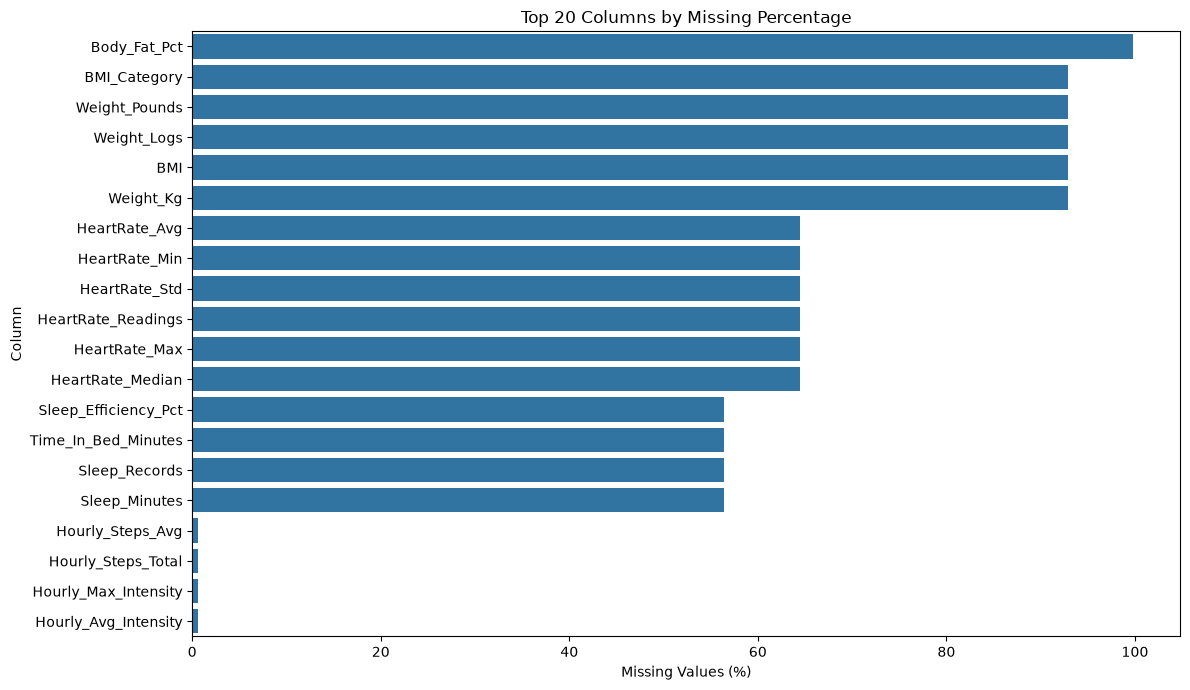

In [ ]:
# Missing-Value Visualization

plt.figure(figsize=(12, 7))

missing_plot = missing_summary.head(20)

sns.barplot(
    data=missing_plot,
    x="Missing_%",
    y="Column"
)

plt.title("Top 20 Columns by Missing Percentage")
plt.xlabel("Missing Values (%)")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

In [ ]:
# Participant Observation Coverage

participant_days = (
    df.groupby("Id")
    .agg(
        Observation_Days=("Date", "nunique"),
        First_Date=("Date", "min"),
        Last_Date=("Date", "max")
    )
    .reset_index()
    .sort_values("Observation_Days", ascending=False)
)

participant_days.head(10)

,Id,Observation_Days,First_Date,Last_Date
0,1503960366,31,2016-04-12,2016-05-12
1,1624580081,31,2016-04-12,2016-05-12
3,1844505072,31,2016-04-12,2016-05-12
4,1927972279,31,2016-04-12,2016-05-12
5,2022484408,31,2016-04-12,2016-05-12
7,2320127002,31,2016-04-12,2016-05-12
6,2026352035,31,2016-04-12,2016-05-12
12,4020332650,31,2016-04-12,2016-05-12
9,2873212765,31,2016-04-12,2016-05-12
16,4445114986,31,2016-04-12,2016-05-12


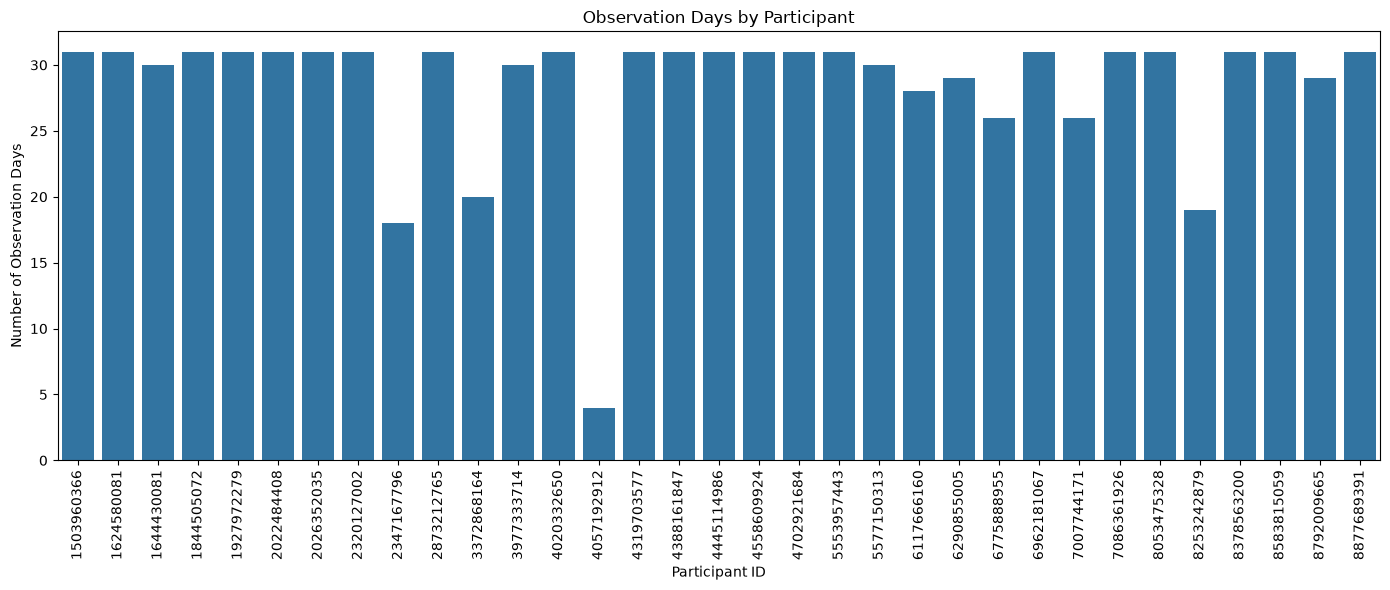

In [ ]:
# Observation Days by Participant

plt.figure(figsize=(14, 6))

sns.barplot(
    data=participant_days,
    x="Id",
    y="Observation_Days"
)

plt.title("Observation Days by Participant")
plt.xlabel("Participant ID")
plt.ylabel("Number of Observation Days")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

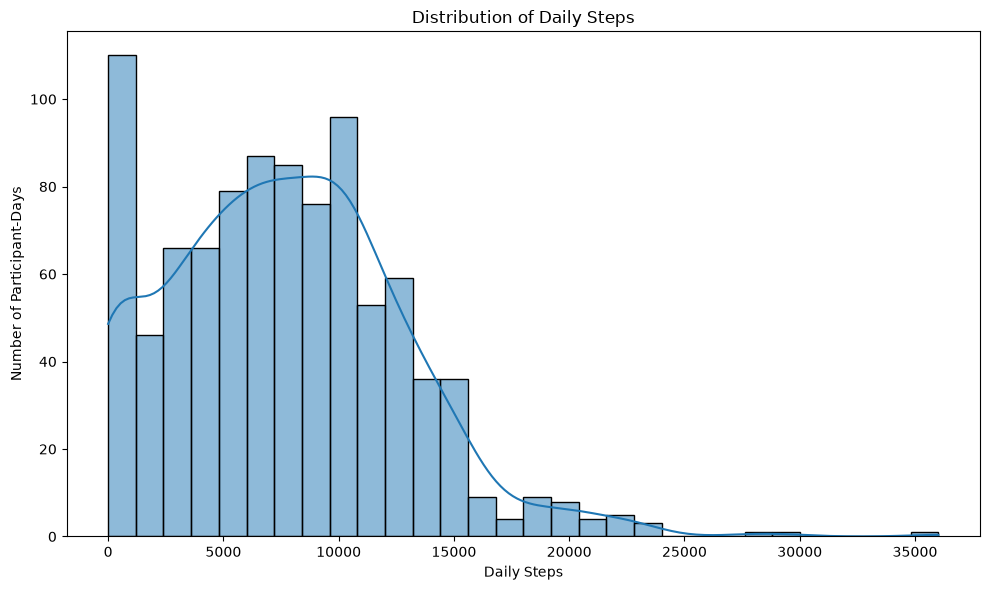

In [ ]:
# Distribution of Daily Steps

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="TotalSteps",
    bins=30,
    kde=True
)

plt.title("Distribution of Daily Steps")
plt.xlabel("Daily Steps")
plt.ylabel("Number of Participant-Days")
plt.tight_layout()
plt.show()

In [ ]:
# Daily Steps Descriptive Statistics

steps_summary = df["TotalSteps"].describe()

steps_summary

count      940.000000
mean      7637.910638
std       5087.150742
min          0.000000
25%       3789.750000
50%       7405.500000
75%      10727.000000
max      36019.000000
Name: TotalSteps, dtype: float64

In [ ]:
# Daily Steps Summary

print(f"Average daily steps: {df['TotalSteps'].mean():,.0f}")
print(f"Median daily steps: {df['TotalSteps'].median():,.0f}")
print(f"Minimum daily steps: {df['TotalSteps'].min():,.0f}")
print(f"Maximum daily steps: {df['TotalSteps'].max():,.0f}")

Average daily steps: 7,638
Median daily steps: 7,406
Minimum daily steps: 0
Maximum daily steps: 36,019


In [133]:
# Step goal achievement
step_goal_summary = (
    df["Meets_10k_Steps"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename_axis("Meets_10k_Steps")
    .reset_index(name="Percentage")
)

step_goal_summary

,Meets_10k_Steps,Percentage
0,False,67.7700
1,True,32.2300


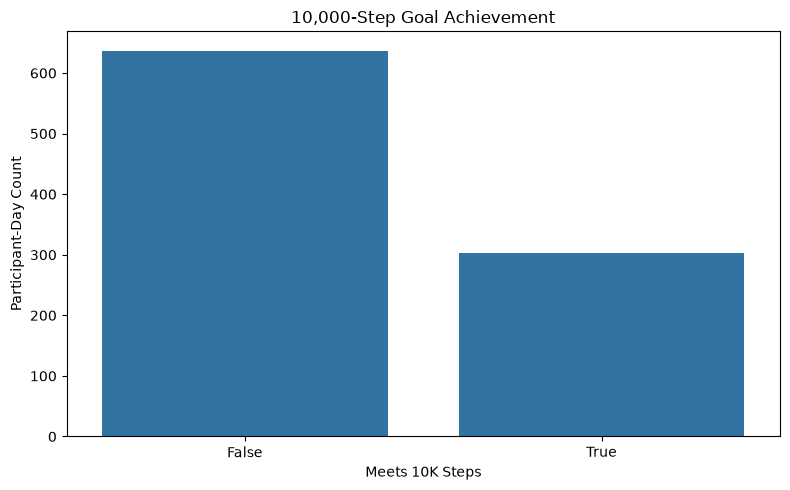

In [ ]:
# 10,000-Step Goal Achievement

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Meets_10k_Steps"
)

plt.title("10,000-Step Goal Achievement")
plt.xlabel("Meets 10K Steps")
plt.ylabel("Participant-Day Count")
plt.tight_layout()
plt.show()

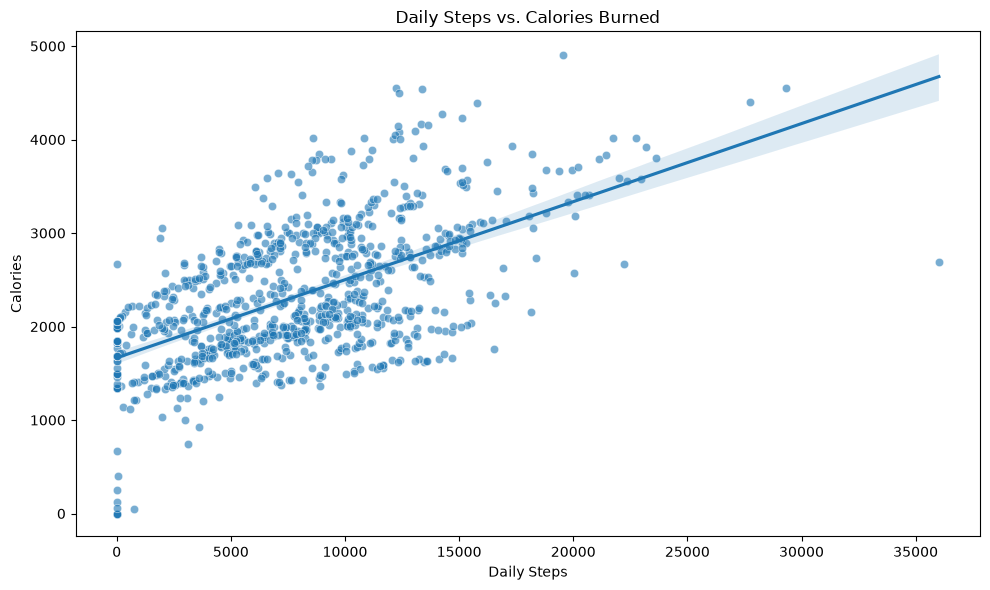

In [ ]:
# Steps and Calorie Expenditure

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="TotalSteps",
    y="Calories",
    alpha=0.6
)

sns.regplot(
    data=df,
    x="TotalSteps",
    y="Calories",
    scatter=False
)

plt.title("Daily Steps vs. Calories Burned")
plt.xlabel("Daily Steps")
plt.ylabel("Calories")
plt.tight_layout()
plt.show()

In [ ]:
# Correlation between Steps and Calories

steps_calories_corr = df[
    ["TotalSteps", "Calories"]
].corr()

steps_calories_corr

,TotalSteps,Calories
TotalSteps,1.000000,0.591568
Calories,0.591568,1.000000


#### E. **Activity Intensity and Daily Minutes**

Daily activity is decomposed into Very Active, Fairly Active, Lightly Active, and Sedentary time.

The analysis examines how participant-days are distributed across different intensity levels and summarizes the average time spent in each category.


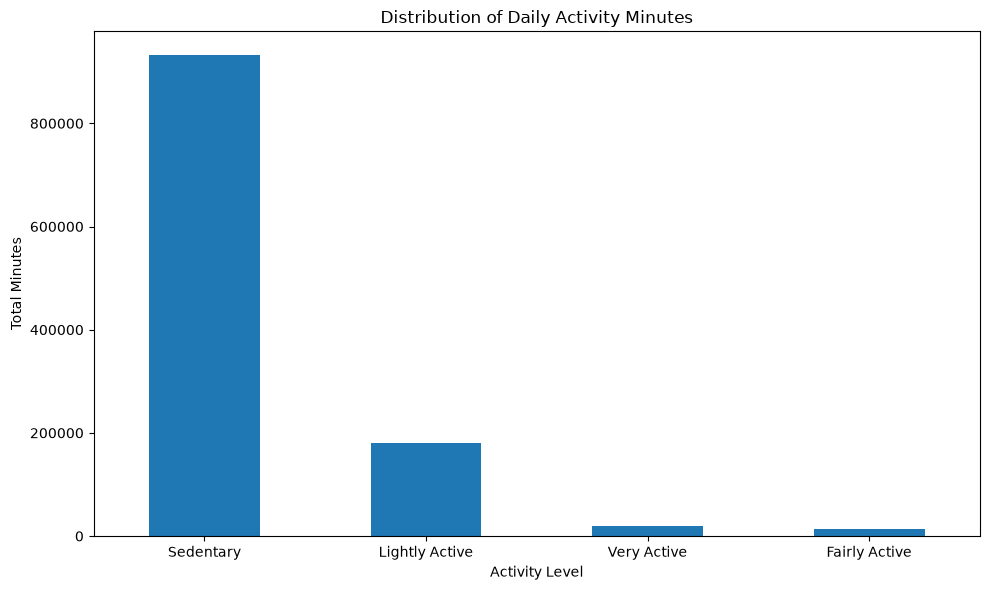

In [ ]:
# Daily Activity Minutes Distribution

activity_minutes = {
    "Very Active": df["VeryActiveMinutes"].sum(),
    "Fairly Active": df["FairlyActiveMinutes"].sum(),
    "Lightly Active": df["LightlyActiveMinutes"].sum(),
    "Sedentary": df["SedentaryMinutes"].sum()
}

activity_minutes_series = pd.Series(activity_minutes)

plt.figure(figsize=(10, 6))

activity_minutes_series.sort_values(ascending=False).plot(
    kind="bar"
)

plt.title("Distribution of Daily Activity Minutes")
plt.xlabel("Activity Level")
plt.ylabel("Total Minutes")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Average Daily Minutes by Activity Level

activity_avg = pd.DataFrame({
    "Activity Level": [
        "Very Active",
        "Fairly Active",
        "Lightly Active",
        "Sedentary"
    ],
    "Average Minutes": [
        df["VeryActiveMinutes"].mean(),
        df["FairlyActiveMinutes"].mean(),
        df["LightlyActiveMinutes"].mean(),
        df["SedentaryMinutes"].mean()
    ]
})

display(activity_avg)

,Activity Level,Average Minutes
0,Very Active,21.164894
1,Fairly Active,13.564894
2,Lightly Active,192.812766
3,Sedentary,991.210638


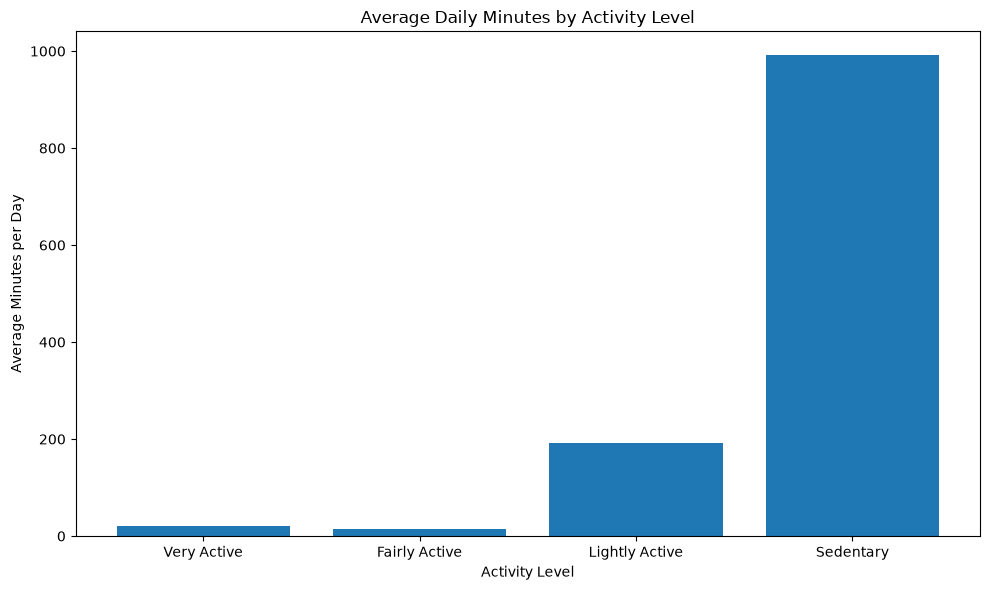

In [ ]:
# Average Daily Activity by Intensity

plt.figure(figsize=(10, 6))

plt.bar(
    activity_avg["Activity Level"],
    activity_avg["Average Minutes"]
)

plt.title("Average Daily Minutes by Activity Level")
plt.xlabel("Activity Level")
plt.ylabel("Average Minutes per Day")

plt.tight_layout()
plt.show()

#### F. **Distribution of Daily Calories**

Daily calorie expenditure is visualized to assess its distribution, spread, and potential extreme observations.

The result provides context for the subsequent activity-calorie relationship and statistical analysis.


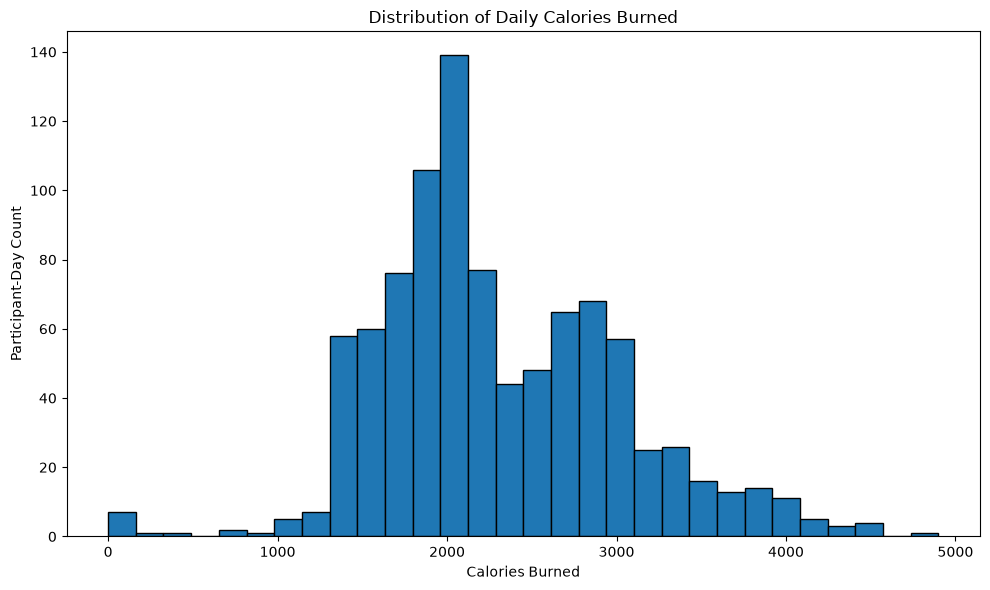

In [ ]:
# Distribution of Daily Calories Burned

plt.figure(figsize=(10, 6))

plt.hist(
    df["Calories"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Daily Calories Burned")
plt.xlabel("Calories Burned")
plt.ylabel("Participant-Day Count")

plt.tight_layout()
plt.show()

#### G. **Daily Calorie Summary**

Descriptive statistics are calculated for daily calorie expenditure to summarize its central tendency and variability.


In [ ]:
# Calories Summary

calories_summary = df["Calories"].describe()

display(calories_summary)

print(f"Average daily calories: {df['Calories'].mean():,.0f}")
print(f"Median daily calories: {df['Calories'].median():,.0f}")
print(f"Minimum daily calories: {df['Calories'].min():,.0f}")
print(f"Maximum daily calories: {df['Calories'].max():,.0f}")

count     940.000000
mean     2303.609574
std       718.166862
min         0.000000
25%      1828.500000
50%      2134.000000
75%      2793.250000
max      4900.000000
Name: Calories, dtype: float64

Average daily calories: 2,304
Median daily calories: 2,134
Minimum daily calories: 0
Maximum daily calories: 4,900


#### H. **Activity by Day of Week**

Average daily steps are compared across the seven days of the week.

This helps identify recurring weekly patterns in participant movement behavior.


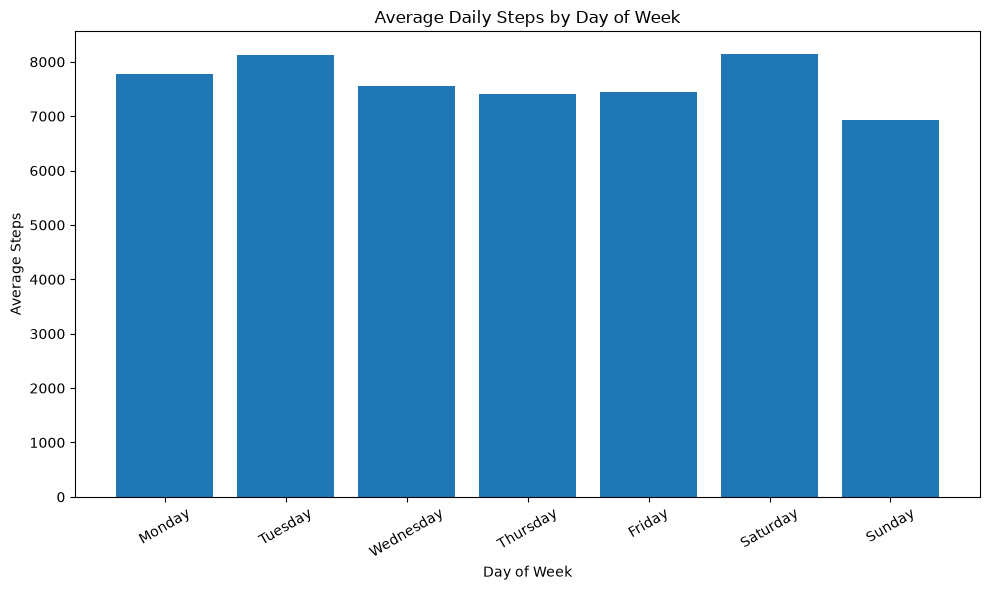

In [ ]:
# Average Steps by Day of Week

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_steps = (
    df.groupby("Day_Of_Week")["TotalSteps"]
    .mean()
    .reindex(weekday_order)
)

plt.figure(figsize=(10, 6))

plt.bar(
    weekday_steps.index,
    weekday_steps.values
)

plt.title("Average Daily Steps by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Steps")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#### I. Weekday versus Weekend Activity

Daily step behavior is grouped into weekday and weekend observations.

The comparison provides a simple view of whether movement levels change across the weekly cycle.


In [ ]:
# Weekday vs Weekend Activity

weekend_steps = (
    df.groupby("Is_Weekend")["TotalSteps"]
    .mean()
)

weekend_steps.index = [
    "Weekday" if value == False else "Weekend"
    for value in weekend_steps.index
]

display(
    weekend_steps.rename("Average Steps").to_frame()
)

,Average Steps
Weekday,7668.699281
Weekend,7550.571429


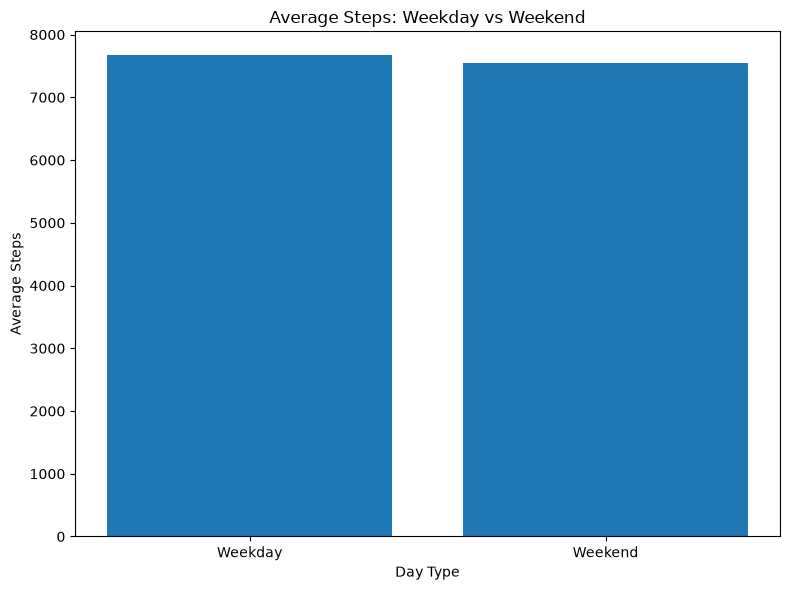

In [ ]:
# Weekday vs Weekend Steps

plt.figure(figsize=(8, 6))

plt.bar(
    weekend_steps.index,
    weekend_steps.values
)

plt.title("Average Steps: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Steps")

plt.tight_layout()
plt.show()

#### J. **Daily Activity Trend**

Average daily steps are plotted across the study period to examine changes in movement behavior over time.

This provides a time-based view that complements participant-level and weekday-level comparisons.


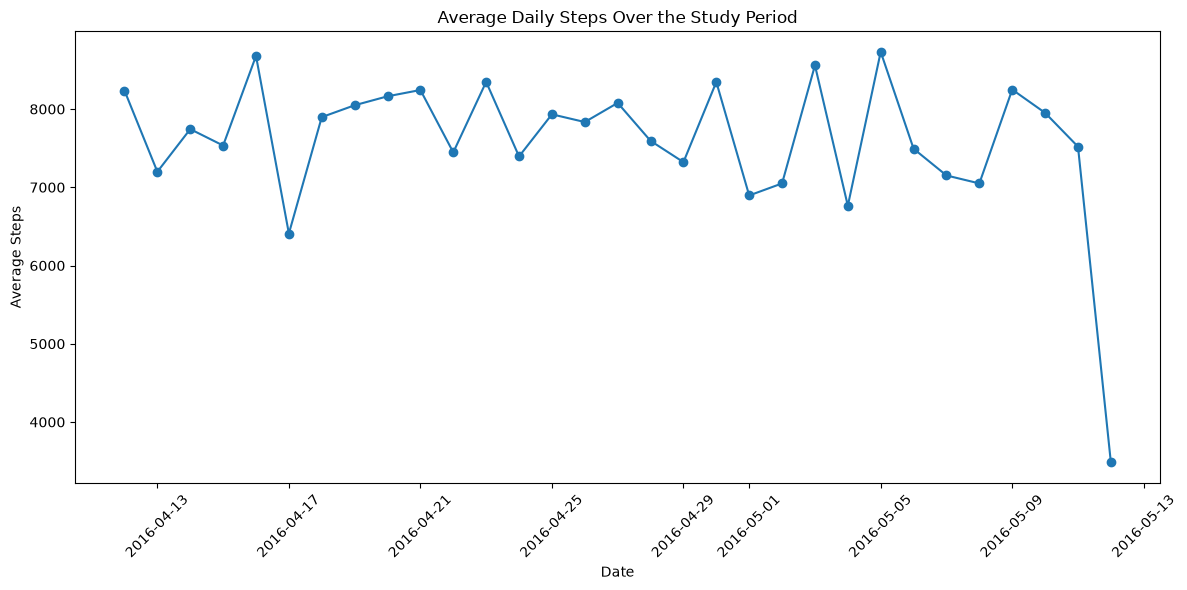

In [ ]:
# Average Daily Steps Over the Study Period

daily_steps_trend = (
    df.groupby("Date")["TotalSteps"]
    .mean()
)

plt.figure(figsize=(12, 6))

plt.plot(
    daily_steps_trend.index,
    daily_steps_trend.values,
    marker="o"
)

plt.title("Average Daily Steps Over the Study Period")
plt.xlabel("Date")
plt.ylabel("Average Steps")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### K. **Activity by Study Week**

Daily steps are aggregated by study week to smooth short-term daily variation.

The resulting weekly summary is used to assess broader changes in activity over the observation period.


In [ ]:
# Average Steps by Study Week

weekly_steps = (
    df.groupby("Week")["TotalSteps"]
    .mean()
)

display(
    weekly_steps.rename("Average Steps").to_frame()
)

,Average Steps
Week,
15,7634.479592
16,7934.370536
17,7719.158371
18,7547.228856
19,6969.918367


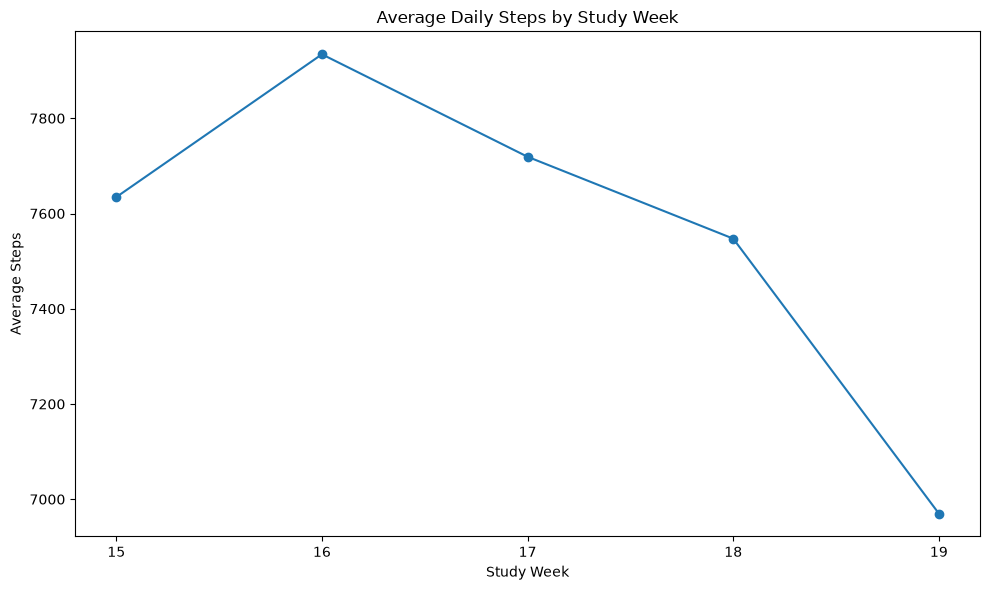

In [ ]:
# Weekly Activity Trend

plt.figure(figsize=(10, 6))

plt.plot(
    weekly_steps.index,
    weekly_steps.values,
    marker="o"
)

plt.title("Average Daily Steps by Study Week")
plt.xlabel("Study Week")
plt.ylabel("Average Steps")

plt.xticks(weekly_steps.index)
plt.tight_layout()
plt.show()

#### L. **Sleep Analysis**

Sleep is analyzed separately because sleep records are not available for every participant-date.

The analysis focuses on:

- Sleep data coverage
- Sleep duration
- Seven-hour target achievement
- Sleep duration versus activity
- Sleep duration versus calorie expenditure
- Sleep efficiency
- Sleep behavior by day of week


In [ ]:
# Sleep Summary

sleep_df = df[df["Sleep_Minutes"].notna()].copy()

print("Sleep records available:", len(sleep_df))
print("Participants with sleep data:", sleep_df["Id"].nunique())

print("\nSleep Duration Summary:")
print(
    sleep_df["Sleep_Minutes"]
    .describe()
)

print("\nAverage sleep duration:",
      round(sleep_df["Sleep_Minutes"].mean() / 60, 2),
      "hours")

print("Median sleep duration:",
      round(sleep_df["Sleep_Minutes"].median() / 60, 2),
      "hours")

print("Minimum sleep duration:",
      round(sleep_df["Sleep_Minutes"].min() / 60, 2),
      "hours")

print("Maximum sleep duration:",
      round(sleep_df["Sleep_Minutes"].max() / 60, 2),
      "hours")

Sleep records available: 410
Participants with sleep data: 24

Sleep Duration Summary:
count    410.000000
mean     419.173171
std      118.635918
min       58.000000
25%      361.000000
50%      432.500000
75%      490.000000
max      796.000000
Name: Sleep_Minutes, dtype: float64

Average sleep duration: 6.99 hours
Median sleep duration: 7.21 hours
Minimum sleep duration: 0.97 hours
Maximum sleep duration: 13.27 hours


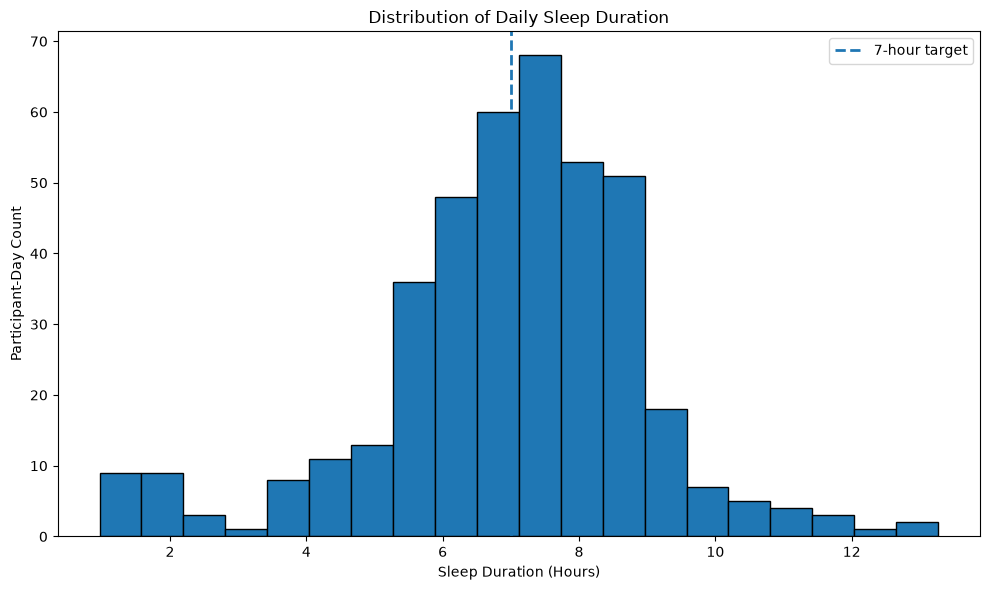

In [ ]:
# Distribution of Sleep Duration

plt.figure(figsize=(10, 6))

plt.hist(
    sleep_df["Sleep_Minutes"] / 60,
    bins=20,
    edgecolor="black"
)

plt.axvline(
    7,
    linestyle="--",
    linewidth=2,
    label="7-hour target"
)

plt.title("Distribution of Daily Sleep Duration")
plt.xlabel("Sleep Duration (Hours)")
plt.ylabel("Participant-Day Count")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Sleep Target Achievement

sleep_target = (
    sleep_df["Sleep_7h_Target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename_axis("Sleep_7h_Target")
    .reset_index(name="Percentage")
)

sleep_target

,Sleep_7h_Target,Percentage
0,True,55.85
1,False,44.15


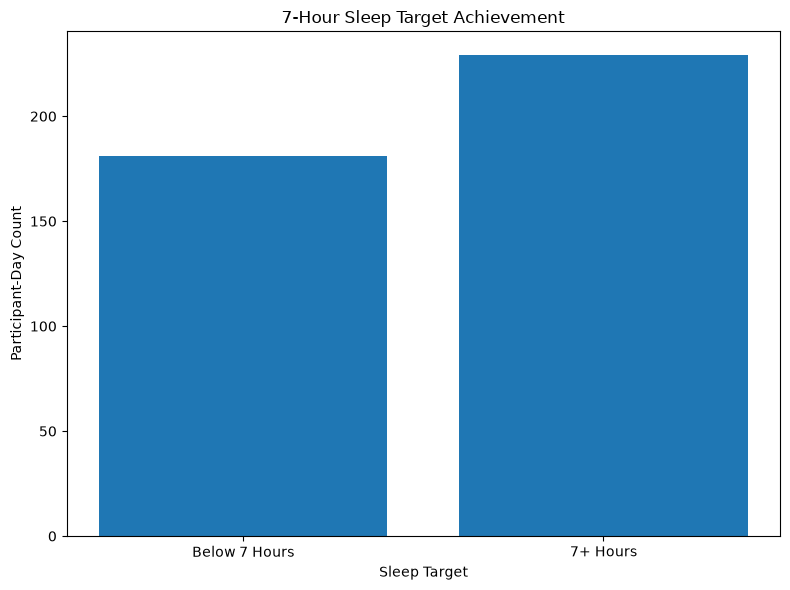

In [ ]:
# 7-Hour Sleep Target Achievement

sleep_counts = sleep_df["Sleep_7h_Target"].value_counts()

plt.figure(figsize=(8, 6))

plt.bar(
    ["Below 7 Hours", "7+ Hours"],
    [
        sleep_counts.get(False, 0),
        sleep_counts.get(True, 0)
    ]
)

plt.title("7-Hour Sleep Target Achievement")
plt.xlabel("Sleep Target")
plt.ylabel("Participant-Day Count")

plt.tight_layout()
plt.show()

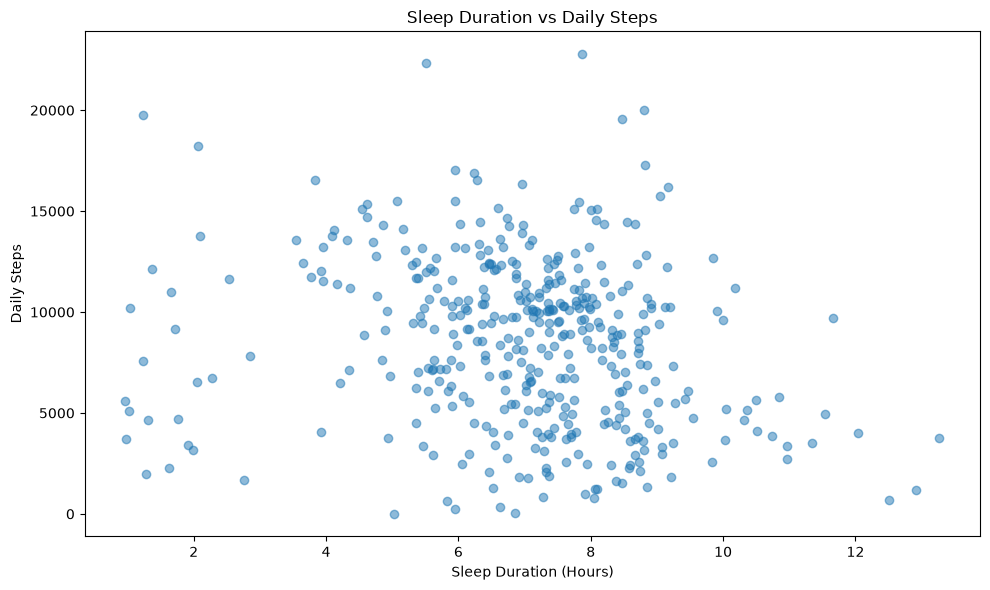

In [ ]:
# Sleep Duration vs Daily Steps

sleep_steps = sleep_df[
    ["Sleep_Minutes", "TotalSteps"]
].dropna()

plt.figure(figsize=(10, 6))

plt.scatter(
    sleep_steps["Sleep_Minutes"] / 60,
    sleep_steps["TotalSteps"],
    alpha=0.5
)

plt.title("Sleep Duration vs Daily Steps")
plt.xlabel("Sleep Duration (Hours)")
plt.ylabel("Daily Steps")

plt.tight_layout()
plt.show()

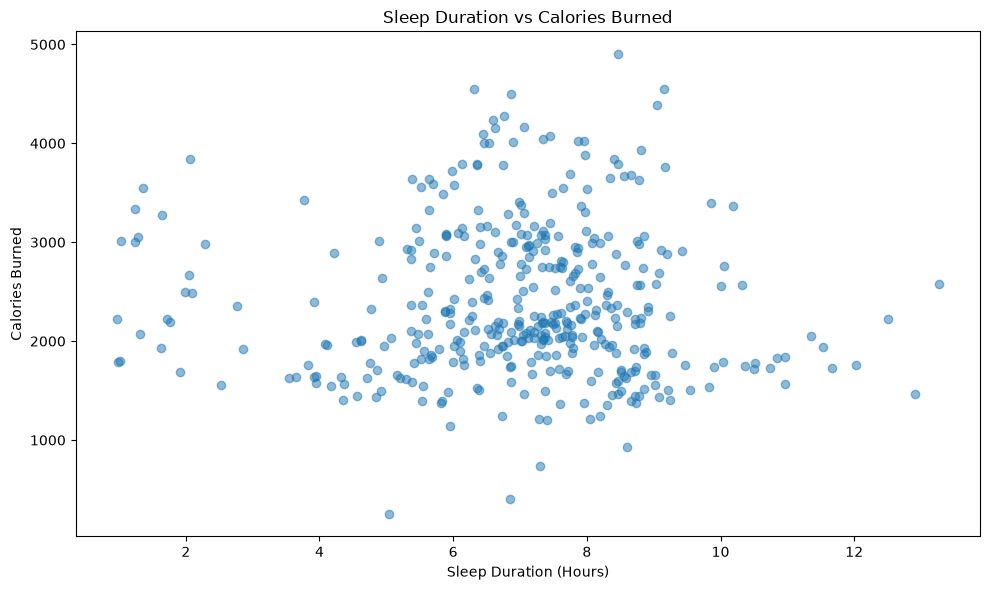

In [ ]:
# Sleep Duration vs Calories

sleep_calories = sleep_df[
    ["Sleep_Minutes", "Calories"]
].dropna()

plt.figure(figsize=(10, 6))

plt.scatter(
    sleep_calories["Sleep_Minutes"] / 60,
    sleep_calories["Calories"],
    alpha=0.5
)

plt.title("Sleep Duration vs Calories Burned")
plt.xlabel("Sleep Duration (Hours)")
plt.ylabel("Calories Burned")

plt.tight_layout()
plt.show()

In [ ]:
# Sleep Correlations

sleep_corr = sleep_df[
    [
        "Sleep_Minutes",
        "Sleep_Efficiency_Pct",
        "TotalSteps",
        "Calories",
        "Total_Active_Minutes",
        "VeryActiveMinutes",
        "SedentaryMinutes"
    ]
].corr()

sleep_corr

,Sleep_Minutes,Sleep_Efficiency_Pct,TotalSteps,Calories,Total_Active_Minutes,VeryActiveMinutes,SedentaryMinutes
Sleep_Minutes,1.000000,0.264526,-0.190344,-0.031699,-0.069294,-0.088127,-0.601073
Sleep_Efficiency_Pct,0.264526,1.000000,-0.110023,0.294862,0.040018,0.061687,0.019756
TotalSteps,-0.190344,-0.110023,1.000000,0.406301,0.744648,0.543694,-0.130036
Calories,-0.031699,0.294862,0.406301,1.000000,0.389983,0.611198,0.098656
Total_Active_Minutes,-0.069294,0.040018,0.744648,0.389983,1.000000,0.278751,-0.262689
VeryActiveMinutes,-0.088127,0.061687,0.543694,0.611198,0.278751,1.000000,-0.016484
SedentaryMinutes,-0.601073,0.019756,-0.130036,0.098656,-0.262689,-0.016484,1.000000


In [ ]:
# Average Sleep Duration by Day of Week

sleep_by_day = (
    sleep_df
    .groupby("Day_Of_Week", as_index=False)
    .agg(
        Average_Sleep_Minutes=("Sleep_Minutes", "mean"),
        Sleep_Records=("Sleep_Minutes", "count")
    )
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

sleep_by_day["Day_Of_Week"] = pd.Categorical(
    sleep_by_day["Day_Of_Week"],
    categories=day_order,
    ordered=True
)

sleep_by_day = sleep_by_day.sort_values("Day_Of_Week")

sleep_by_day["Average_Sleep_Hours"] = (
    sleep_by_day["Average_Sleep_Minutes"] / 60
).round(2)

sleep_by_day

,Day_Of_Week,Average_Sleep_Minutes,Sleep_Records,Average_Sleep_Hours
1,Monday,419.500000,46,6.99
5,Tuesday,404.538462,65,6.74
6,Wednesday,434.681818,66,7.24
4,Thursday,401.296875,64,6.69
0,Friday,405.421053,57,6.76
2,Saturday,419.070175,57,6.98
3,Sunday,452.745455,55,7.55


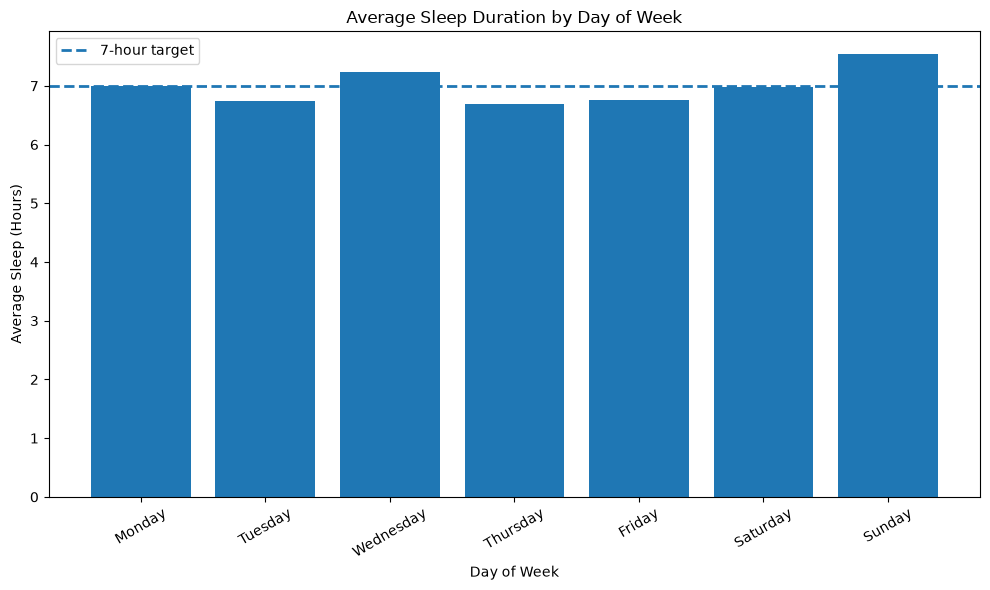

In [ ]:
# Average Sleep Duration by Day of Week

plt.figure(figsize=(10, 6))

plt.bar(
    sleep_by_day["Day_Of_Week"],
    sleep_by_day["Average_Sleep_Hours"]
)

plt.axhline(
    7,
    linestyle="--",
    linewidth=2,
    label="7-hour target"
)

plt.title("Average Sleep Duration by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sleep (Hours)")
plt.xticks(rotation=30)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Sleep Efficiency Summary

sleep_efficiency = sleep_df[
    "Sleep_Efficiency_Pct"
].dropna()

print(
    sleep_efficiency.describe()
)

print(
    "\nAverage sleep efficiency:",
    round(sleep_efficiency.mean(), 2),
    "%"
)

print(
    "Median sleep efficiency:",
    round(sleep_efficiency.median(), 2),
    "%"
)

print(
    "Minimum sleep efficiency:",
    round(sleep_efficiency.min(), 2),
    "%"
)

print(
    "Maximum sleep efficiency:",
    round(sleep_efficiency.max(), 2),
    "%"
)

count    410.000000
mean      91.646671
std        8.728389
min       49.836000
25%       91.181250
50%       94.263500
75%       96.064250
max      100.000000
Name: Sleep_Efficiency_Pct, dtype: float64

Average sleep efficiency: 91.65 %
Median sleep efficiency: 94.26 %
Minimum sleep efficiency: 49.84 %
Maximum sleep efficiency: 100.0 %


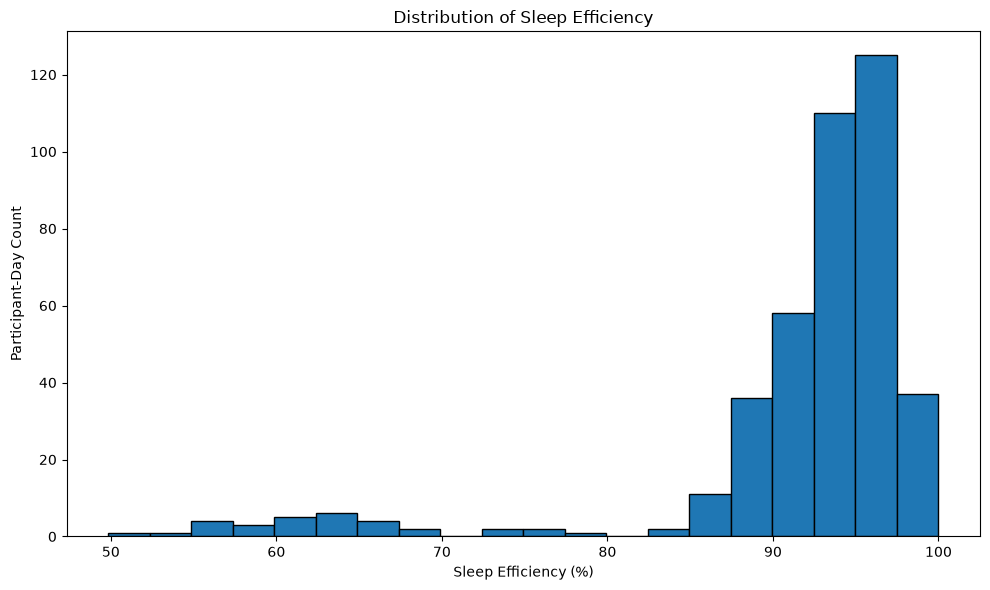

In [ ]:
# Distribution of Sleep Efficiency

plt.figure(figsize=(10, 6))

plt.hist(
    sleep_efficiency,
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Sleep Efficiency")
plt.xlabel("Sleep Efficiency (%)")
plt.ylabel("Participant-Day Count")

plt.tight_layout()
plt.show()

#### M. **Participant-Level Activity Analysis**

The next stage shifts from participant-day observations to participant-level summaries.

For each participant, average steps, calories, active minutes, and sedentary behavior are summarized to identify differences in typical engagement.


In [ ]:
# Participant-Level Activity Summary

participant_activity = (
    df.groupby("Id")
    .agg(
        Avg_Steps=("TotalSteps", "mean"),
        Avg_Calories=("Calories", "mean"),
        Avg_Active_Minutes=("Total_Active_Minutes", "mean"),
        Avg_VeryActive_Minutes=("VeryActiveMinutes", "mean"),
        Avg_LightlyActive_Minutes=("LightlyActiveMinutes", "mean"),
        Avg_Sedentary_Minutes=("SedentaryMinutes", "mean"),
        Avg_Total_Distance=("TotalDistance", "mean"),
        Days_Recorded=("Date", "count")
    )
    .reset_index()
)

participant_activity.head()

,Id,Avg_Steps,Avg_Calories,Avg_Active_Minutes,Avg_VeryActive_Minutes,Avg_LightlyActive_Minutes,Avg_Sedentary_Minutes,Avg_Total_Distance,Days_Recorded
0,1503960366,12116.741935,1816.419355,277.806452,38.709677,219.935484,848.161290,7.809677,31
1,1624580081,5743.903226,1483.354839,167.967742,8.677419,153.483871,1257.741935,3.914839,31
2,1644430081,7282.966667,2811.300000,209.400000,9.566667,178.466667,1161.866667,5.295333,30
3,1844505072,2580.064516,1573.483871,116.870968,0.129032,115.451613,1206.612903,1.706129,31
4,1927972279,916.129032,2172.806452,40.677419,1.322581,38.580645,1317.419355,0.634516,31


In [ ]:
# Participant Activity Statistics

display(
    participant_activity[
        [
            "Avg_Steps",
            "Avg_Calories",
            "Avg_Active_Minutes",
            "Avg_VeryActive_Minutes",
            "Avg_LightlyActive_Minutes",
            "Avg_Sedentary_Minutes",
            "Avg_Total_Distance"
        ]
    ].describe().round(2)
)

,Avg_Steps,Avg_Calories,Avg_Active_Minutes,Avg_VeryActive_Minutes,Avg_LightlyActive_Minutes,Avg_Sedentary_Minutes,Avg_Total_Distance
count,33.00,33.00,33.00,33.00,33.00,33.00,33.00
mean,7519.27,2282.44,225.09,20.31,191.52,999.15,5.40
std,3576.34,562.76,81.79,23.80,75.69,227.68,2.77
min,916.13,1483.35,40.68,0.10,38.58,662.32,0.63
25%,5566.87,1916.97,170.16,3.58,143.84,766.42,3.45
50%,7282.97,2131.77,244.68,10.39,206.19,1077.55,5.30
75%,9519.67,2599.62,286.56,23.42,245.81,1206.61,6.91
max,16040.03,3436.58,341.15,87.33,327.90,1317.42,13.21


#### N. **Average Daily Steps by Participant**

Participants are ordered by their average daily steps to highlight differences in typical movement behavior.

This is a descriptive comparison and should be interpreted alongside observation coverage.


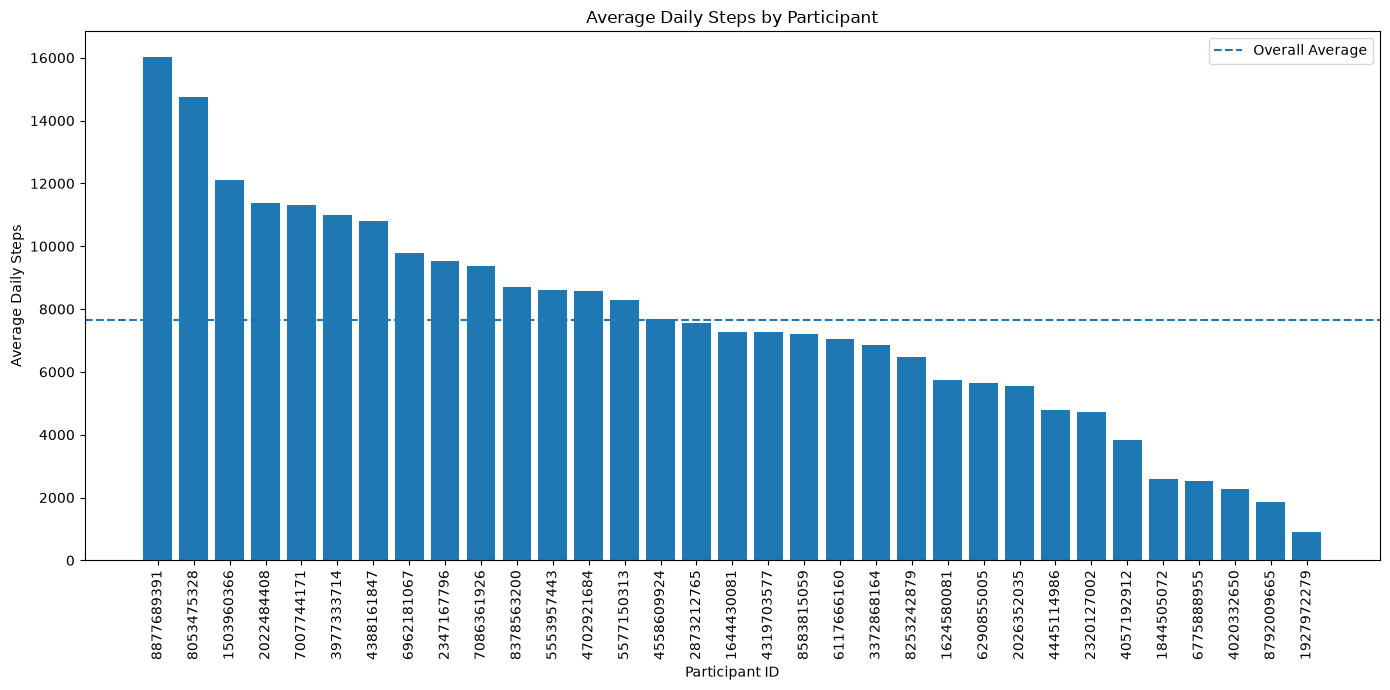

In [ ]:
# Average Daily Steps by Participant

participant_steps = (
    participant_activity
    .sort_values("Avg_Steps", ascending=False)
)

plt.figure(figsize=(14, 7))

plt.bar(
    participant_steps["Id"].astype(str),
    participant_steps["Avg_Steps"]
)

plt.axhline(
    df["TotalSteps"].mean(),
    linestyle="--",
    label="Overall Average"
)

plt.title("Average Daily Steps by Participant")
plt.xlabel("Participant ID")
plt.ylabel("Average Daily Steps")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

#### O. **Active versus Sedentary Minutes by Participant**

Participant-level active and sedentary time are compared to show how daily engagement differs across individuals.

The visualization emphasizes that movement behavior includes both active and inactive time.


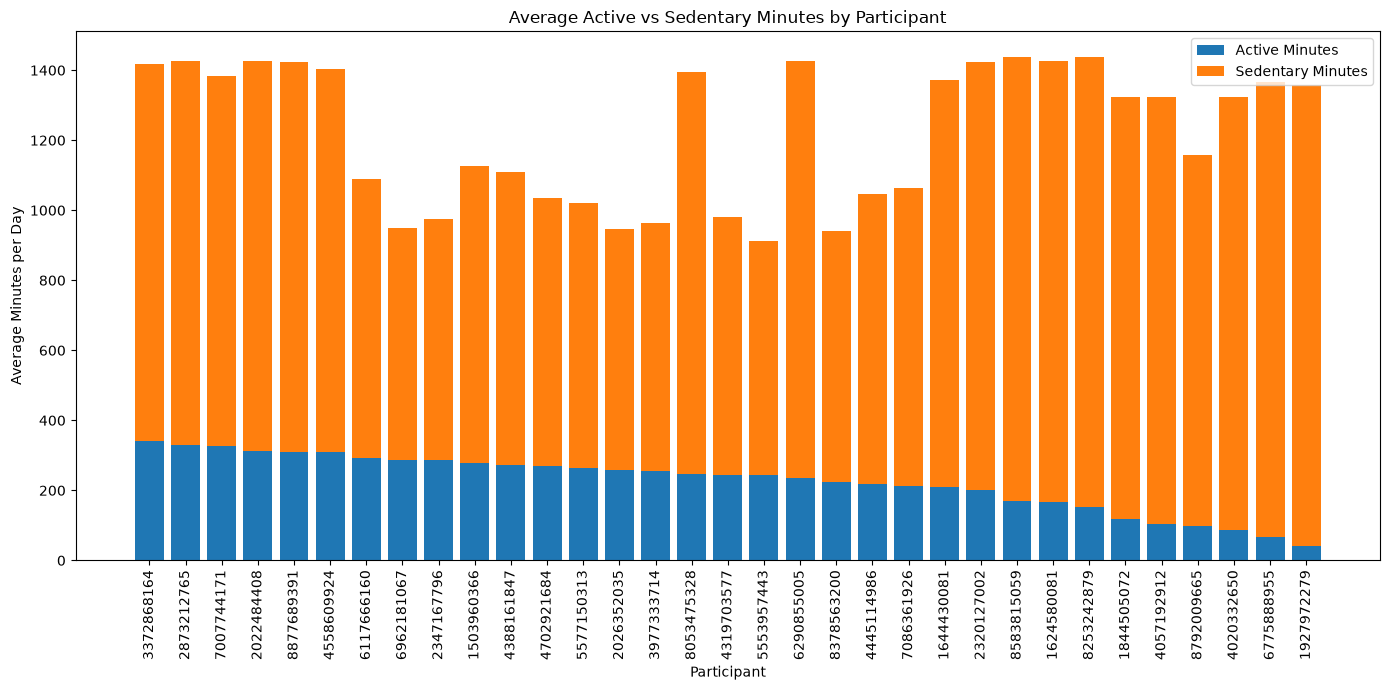

In [ ]:
# Active vs Sedentary Minutes by Participant

participant_activity_plot = (
    participant_activity
    .sort_values("Avg_Active_Minutes", ascending=False)
)

x = range(len(participant_activity_plot))

plt.figure(figsize=(14, 7))

plt.bar(
    x,
    participant_activity_plot["Avg_Active_Minutes"],
    label="Active Minutes"
)

plt.bar(
    x,
    participant_activity_plot["Avg_Sedentary_Minutes"],
    bottom=participant_activity_plot["Avg_Active_Minutes"],
    label="Sedentary Minutes"
)

plt.title("Average Active vs Sedentary Minutes by Participant")
plt.xlabel("Participant")
plt.ylabel("Average Minutes per Day")
plt.xticks(
    x,
    participant_activity_plot["Id"].astype(str),
    rotation=90
)
plt.legend()
plt.tight_layout()
plt.show()

#### P. **Daily Activity Trend Summary**

Daily activity measures are aggregated across participants to provide a consolidated time-series view of steps, calories, and related measures.


In [ ]:
# Daily Activity Trend

daily_activity = (
    df.groupby("Date")
      .agg(
          Avg_Steps=("TotalSteps", "mean"),
          Avg_Calories=("Calories", "mean"),
          Avg_Active_Minutes=("Total_Active_Minutes", "mean"),
          Avg_Sedentary_Minutes=("SedentaryMinutes", "mean"),
          Participants=("Id", "nunique")
      )
      .reset_index()
      .sort_values("Date")
)

daily_activity.head()

,Date,Avg_Steps,Avg_Calories,Avg_Active_Minutes,Avg_Sedentary_Minutes,Participants
0,2016-04-12,8236.848485,2390.696970,229.151515,1026.212121,33
1,2016-04-13,7198.727273,2286.636364,212.666667,1021.787879,33
2,2016-04-14,7743.575758,2356.393939,234.333333,1010.030303,33
3,2016-04-15,7533.848485,2355.181818,242.909091,961.060606,33
4,2016-04-16,8679.156250,2392.937500,236.781250,1002.656250,32


#### Q. **Heart-Rate Analysis**

Heart-rate records are examined as an additional behavioral measure.

Because heart-rate data is not available for every participant-date, coverage is reported before distribution and relationship analyses are performed.


In [ ]:
# Heart Rate Summary

heart_rate_df = df[df["HeartRate_Avg"].notna()].copy()

print("Heart-rate records available:", len(heart_rate_df))
print("Participants with heart-rate data:", heart_rate_df["Id"].nunique())
print("Average heart rate:", f"{heart_rate_df['HeartRate_Avg'].mean():.1f} bpm")
print("Median heart rate:", f"{heart_rate_df['HeartRate_Avg'].median():.1f} bpm")

heart_rate_df[
    [
        "HeartRate_Min",
        "HeartRate_Avg",
        "HeartRate_Median",
        "HeartRate_Max"
    ]
].describe()

Heart-rate records available: 334
Participants with heart-rate data: 14
Average heart rate: 78.6 bpm
Median heart rate: 77.5 bpm


,HeartRate_Min,HeartRate_Avg,HeartRate_Median,HeartRate_Max
count,334.000000,334.000000,334.000000,334.000000
mean,52.691617,78.614024,75.071856,138.703593
std,7.427171,10.613275,11.450937,21.687215
min,36.000000,59.377000,55.000000,80.000000
25%,48.000000,70.465500,66.000000,125.000000
50%,52.000000,77.494000,74.000000,135.500000
75%,56.000000,84.933500,82.000000,153.000000
max,71.000000,109.790000,111.000000,203.000000


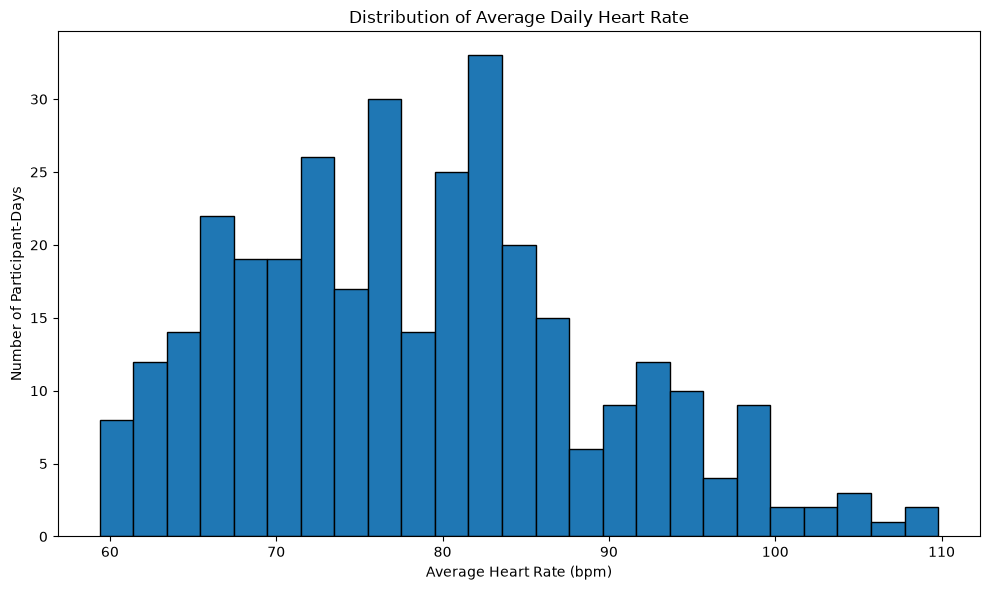

In [ ]:
# Heart Rate Distribution

plt.figure(figsize=(10, 6))

plt.hist(
    heart_rate_df["HeartRate_Avg"],
    bins=25,
    edgecolor="black"
)

plt.title("Distribution of Average Daily Heart Rate")
plt.xlabel("Average Heart Rate (bpm)")
plt.ylabel("Number of Participant-Days")

plt.tight_layout()
plt.show()

In [ ]:
# Average Heart Rate by Participant

participant_heart_rate = (
    heart_rate_df
    .groupby("Id")
    .agg(
        Avg_HeartRate=("HeartRate_Avg", "mean"),
        Min_HeartRate=("HeartRate_Min", "mean"),
        Max_HeartRate=("HeartRate_Max", "mean"),
        HeartRate_Std=("HeartRate_Std", "mean"),
        Days_Recorded=("HeartRate_Avg", "count")
    )
    .sort_values("Avg_HeartRate", ascending=False)
)

participant_heart_rate

,Avg_HeartRate,Min_HeartRate,Max_HeartRate,HeartRate_Std,Days_Recorded
Id,,,,,
6775888955,96.344833,65.833333,136.222222,14.756389,18
7007744171,91.052375,63.375000,139.083333,12.839042,24
2026352035,87.632750,68.250000,112.500000,7.443750,4
4020332650,86.976562,56.812500,134.875000,14.143562,16
6117666160,84.150652,55.043478,133.347826,12.880826,23
8877689391,82.142032,50.000000,157.612903,25.739484,31
4558609924,81.599677,54.903226,131.838710,12.062677,31
2022484408,80.060774,51.612903,146.516129,16.816226,31
6962181067,77.550065,54.096774,143.677419,15.623097,31


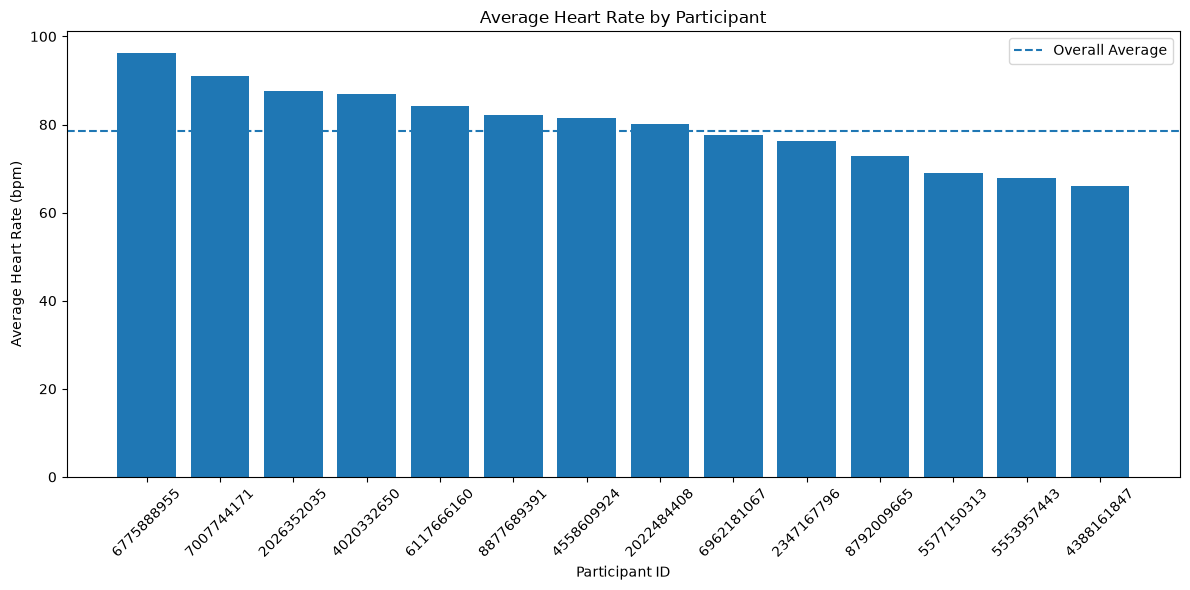

In [ ]:
# Average Heart Rate by Participant

plt.figure(figsize=(12, 6))

plt.bar(
    participant_heart_rate.index.astype(str),
    participant_heart_rate["Avg_HeartRate"]
)

plt.axhline(
    heart_rate_df["HeartRate_Avg"].mean(),
    linestyle="--",
    label="Overall Average"
)

plt.title("Average Heart Rate by Participant")
plt.xlabel("Participant ID")
plt.ylabel("Average Heart Rate (bpm)")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

Correlation between daily steps and calories burned: 0.592


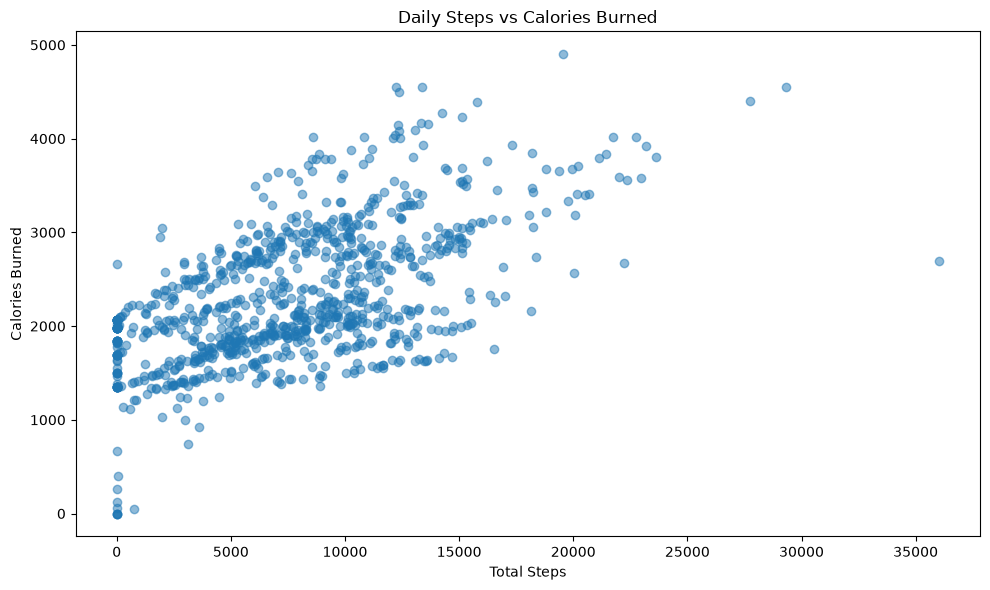

In [ ]:
# Steps vs Calories

steps_calories = df[
    ["TotalSteps", "Calories"]
].dropna()

correlation = steps_calories["TotalSteps"].corr(
    steps_calories["Calories"]
)

print(
    f"Correlation between daily steps and calories burned: "
    f"{correlation:.3f}"
)

plt.figure(figsize=(10, 6))

plt.scatter(
    steps_calories["TotalSteps"],
    steps_calories["Calories"],
    alpha=0.5
)

plt.title("Daily Steps vs Calories Burned")
plt.xlabel("Total Steps")
plt.ylabel("Calories Burned")

plt.tight_layout()
plt.show()

#### R. **Active Minutes Analysis**

Total active minutes are compared with calorie expenditure to examine whether duration of activity is associated with daily energy expenditure.


Correlation between active minutes and calories burned: 0.472


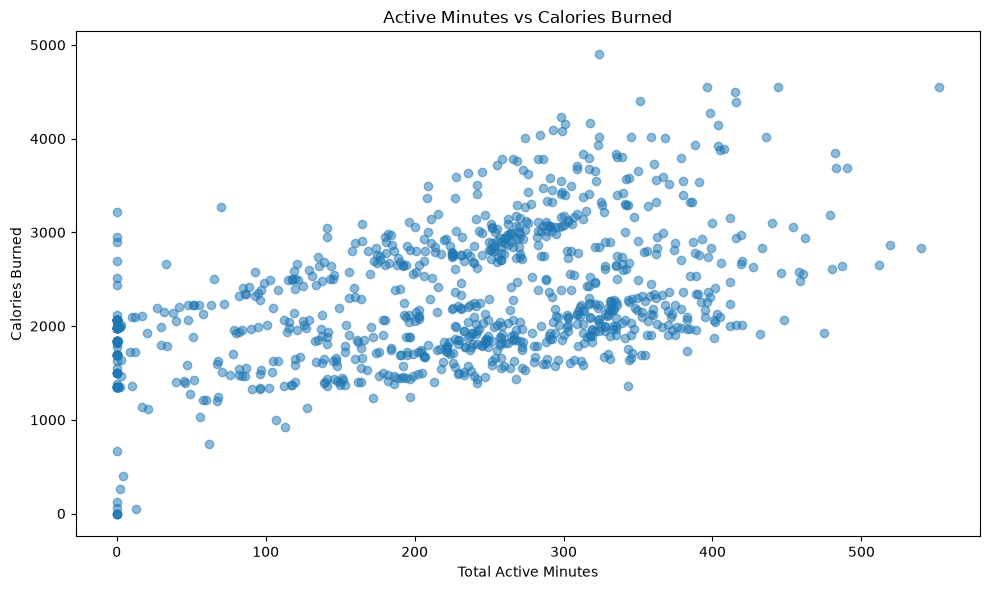

In [ ]:
# Active Minutes vs Calories

active_calories = df[
    ["Total_Active_Minutes", "Calories"]
].dropna()

correlation = active_calories["Total_Active_Minutes"].corr(
    active_calories["Calories"]
)

print(
    f"Correlation between active minutes and calories burned: "
    f"{correlation:.3f}"
)

plt.figure(figsize=(10, 6))

plt.scatter(
    active_calories["Total_Active_Minutes"],
    active_calories["Calories"],
    alpha=0.5
)

plt.title("Active Minutes vs Calories Burned")
plt.xlabel("Total Active Minutes")
plt.ylabel("Calories Burned")

plt.tight_layout()
plt.show()

Correlation between daily steps and active minutes: 0.772


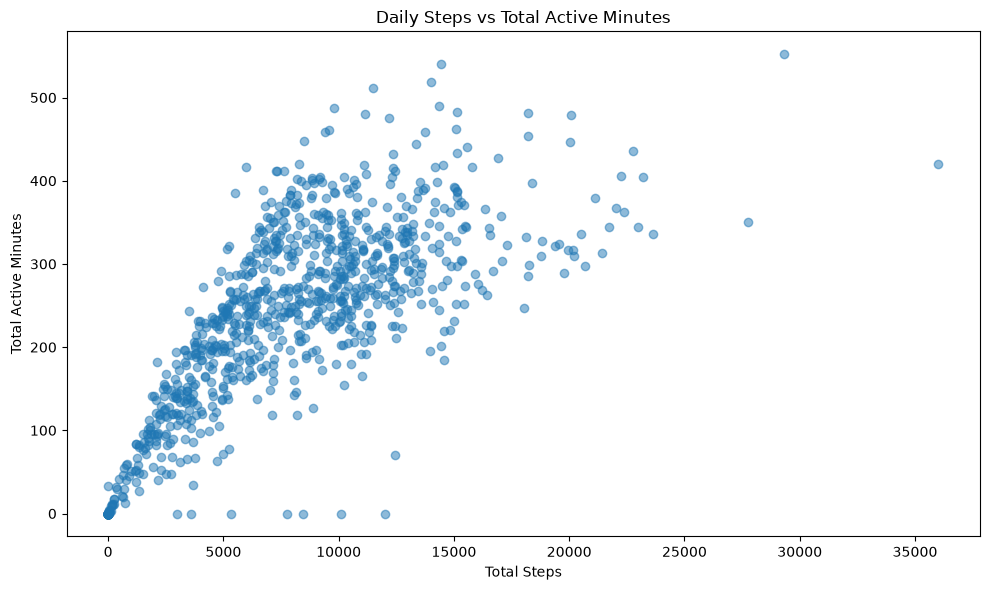

In [ ]:
# Steps vs Active Minutes

steps_active = df[
    ["TotalSteps", "Total_Active_Minutes"]
].dropna()

correlation = steps_active["TotalSteps"].corr(
    steps_active["Total_Active_Minutes"]
)

print(
    f"Correlation between daily steps and active minutes: "
    f"{correlation:.3f}"
)

plt.figure(figsize=(10, 6))

plt.scatter(
    steps_active["TotalSteps"],
    steps_active["Total_Active_Minutes"],
    alpha=0.5
)

plt.title("Daily Steps vs Total Active Minutes")
plt.xlabel("Total Steps")
plt.ylabel("Total Active Minutes")

plt.tight_layout()
plt.show()

Correlation between average heart rate and active minutes: 0.163


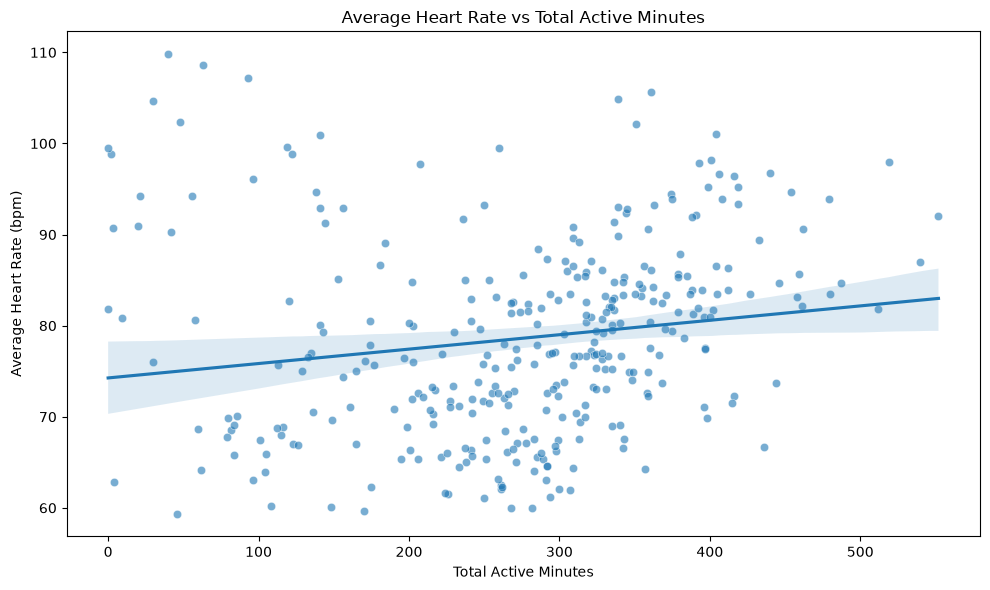

In [ ]:
# Heart Rate vs Active Minutes

heart_activity = heart_rate_df[
    ["HeartRate_Avg", "Total_Active_Minutes"]
].dropna()

correlation = heart_activity["HeartRate_Avg"].corr(
    heart_activity["Total_Active_Minutes"]
)

print(
    f"Correlation between average heart rate and active minutes: "
    f"{correlation:.3f}"
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=heart_activity,
    x="Total_Active_Minutes",
    y="HeartRate_Avg",
    alpha=0.6
)

sns.regplot(
    data=heart_activity,
    x="Total_Active_Minutes",
    y="HeartRate_Avg",
    scatter=False
)

plt.title("Average Heart Rate vs Total Active Minutes")
plt.xlabel("Total Active Minutes")
plt.ylabel("Average Heart Rate (bpm)")

plt.tight_layout()
plt.show()

Correlation between average heart rate and daily steps: 0.169


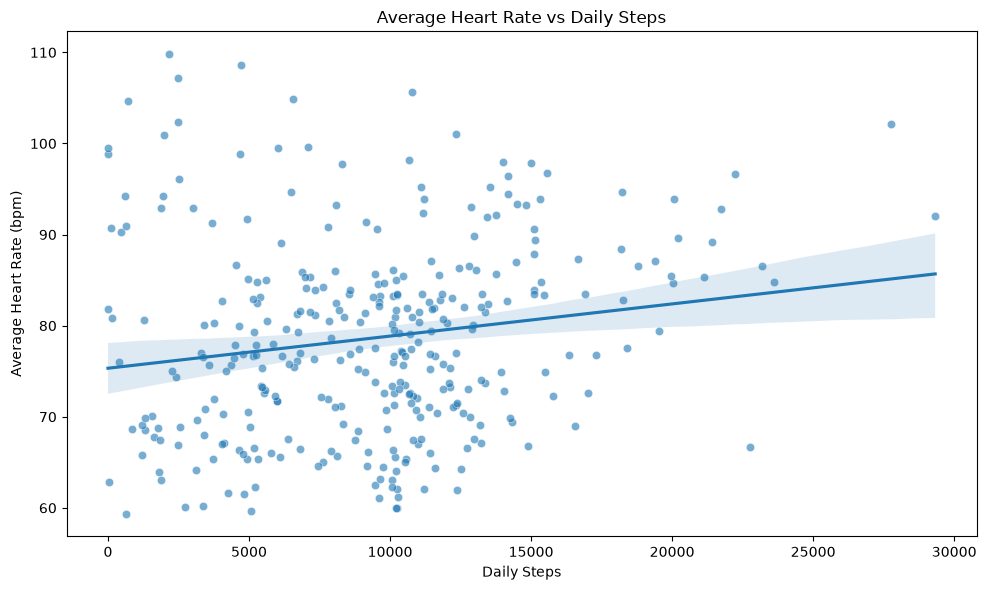

In [ ]:
# Heart Rate vs Daily Steps

heart_steps = heart_rate_df[
    ["HeartRate_Avg", "TotalSteps"]
].dropna()

correlation = heart_steps["HeartRate_Avg"].corr(
    heart_steps["TotalSteps"]
)

print(
    f"Correlation between average heart rate and daily steps: "
    f"{correlation:.3f}"
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=heart_steps,
    x="TotalSteps",
    y="HeartRate_Avg",
    alpha=0.6
)

sns.regplot(
    data=heart_steps,
    x="TotalSteps",
    y="HeartRate_Avg",
    scatter=False
)

plt.title("Average Heart Rate vs Daily Steps")
plt.xlabel("Daily Steps")
plt.ylabel("Average Heart Rate (bpm)")

plt.tight_layout()
plt.show()

Correlation between average heart rate and calories burned: 0.111


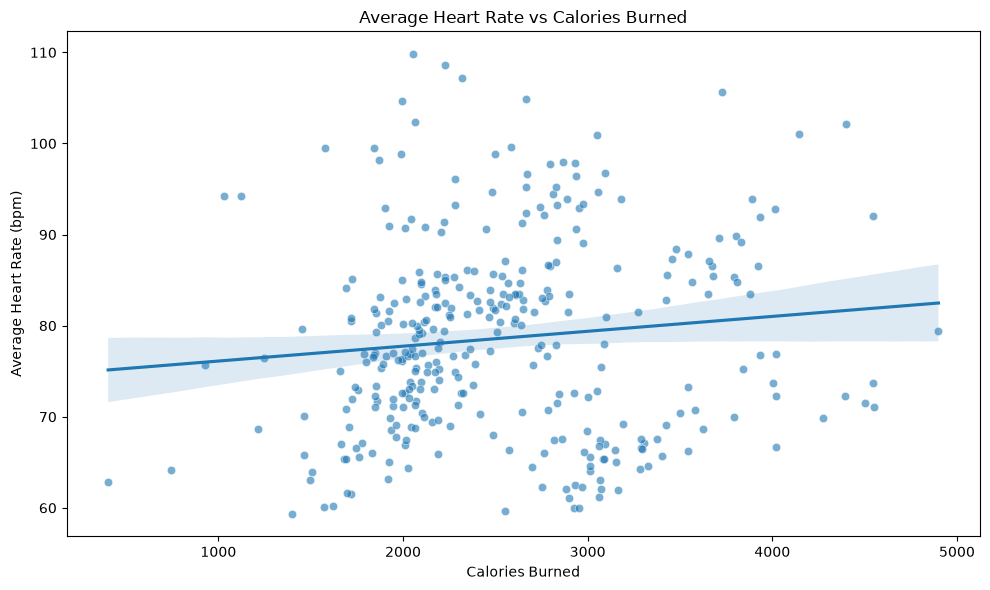

In [ ]:
# Heart Rate vs Calories

heart_calories = heart_rate_df[
    ["HeartRate_Avg", "Calories"]
].dropna()

correlation = heart_calories["HeartRate_Avg"].corr(
    heart_calories["Calories"]
)

print(
    f"Correlation between average heart rate and calories burned: "
    f"{correlation:.3f}"
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=heart_calories,
    x="Calories",
    y="HeartRate_Avg",
    alpha=0.6
)

sns.regplot(
    data=heart_calories,
    x="Calories",
    y="HeartRate_Avg",
    scatter=False
)

plt.title("Average Heart Rate vs Calories Burned")
plt.xlabel("Calories Burned")
plt.ylabel("Average Heart Rate (bpm)")

plt.tight_layout()
plt.show()

In [ ]:
# Heart Rate and Activity Correlations

heart_activity_corr = heart_rate_df[
    [
        "HeartRate_Avg",
        "HeartRate_Min",
        "HeartRate_Max",
        "TotalSteps",
        "Calories",
        "Total_Active_Minutes",
        "VeryActiveMinutes",
        "SedentaryMinutes"
    ]
].corr()

display(
    heart_activity_corr.round(3)
)

,HeartRate_Avg,HeartRate_Min,HeartRate_Max,TotalSteps,Calories,Total_Active_Minutes,VeryActiveMinutes,SedentaryMinutes
HeartRate_Avg,1.000,0.725,0.332,0.169,0.111,0.163,0.095,0.438
HeartRate_Min,0.725,1.000,-0.112,-0.170,-0.369,-0.134,-0.297,0.365
HeartRate_Max,0.332,-0.112,1.000,0.511,0.511,0.363,0.509,0.108
TotalSteps,0.169,-0.170,0.511,1.000,0.631,0.764,0.585,-0.054
Calories,0.111,-0.369,0.511,0.631,1.000,0.505,0.720,0.061
Total_Active_Minutes,0.163,-0.134,0.363,0.764,0.505,1.000,0.387,-0.245
VeryActiveMinutes,0.095,-0.297,0.509,0.585,0.720,0.387,1.000,-0.058
SedentaryMinutes,0.438,0.365,0.108,-0.054,0.061,-0.245,-0.058,1.000


# Statistical Analysis

EDA identifies patterns visually and descriptively. This section tests selected relationships more formally.

### Statistical Objectives

The analysis includes:

- Distribution and normality checks.
- Spearman rank correlations for selected behavioral variables.
- Weekday-versus-weekend comparisons.
- Activity-level group comparisons.
- Sleep and activity relationship analysis.
- Post-hoc pairwise comparisons where appropriate.
- Effect-size analysis to assess the magnitude of group differences.

### Interpretation Framework

Statistical significance indicates evidence of a measurable difference or association under the selected test assumptions. It does **not** establish causation.

Effect size is considered alongside statistical significance so that the analysis does not rely on p-values alone.

Weight and BMI are intentionally excluded from this statistical analysis.


In [82]:
# Statistical Analysis Setup

import numpy as np
import pandas as pd

from scipy import stats

pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("Statistical analysis setup complete.")

Statistical analysis setup complete.


In [83]:
# Distribution and Normality

statistical_columns = [
    "TotalSteps",
    "Calories",
    "Total_Active_Minutes",
    "VeryActiveMinutes",
    "LightlyActiveMinutes",
    "SedentaryMinutes"
]

distribution_results = []

for column in statistical_columns:
    if column not in daily_activity.columns:
        continue

    values = pd.to_numeric(
        daily_activity[column],
        errors="coerce"
    ).dropna()

    if len(values) >= 3:
        # Shapiro-Wilk is limited to 5000 observations
        shapiro_values = values.sample(
            min(len(values), 5000),
            random_state=42
        )

        shapiro_stat, shapiro_p = stats.shapiro(
            shapiro_values
        )

        distribution_results.append({
            "Variable": column,
            "N": len(values),
            "Mean": values.mean(),
            "Median": values.median(),
            "Std": values.std(),
            "Skewness": stats.skew(values),
            "Shapiro_Statistic": shapiro_stat,
            "Shapiro_p": shapiro_p,
            "Normality": (
                "Approximately Normal"
                if shapiro_p >= 0.05
                else "Non-Normal"
            )
        })

distribution_results = pd.DataFrame(
    distribution_results
)

display(
    distribution_results.round(4)
)

""


In [84]:
# Spearman Correlation Analysis

correlation_pairs = [
    ("TotalSteps", "Calories"),
    ("Total_Active_Minutes", "Calories"),
    ("TotalSteps", "Total_Active_Minutes"),
    ("VeryActiveMinutes", "Calories"),
    ("SedentaryMinutes", "Calories")
]

correlation_results = []

for variable_x, variable_y in correlation_pairs:

    if (
        variable_x not in daily_activity.columns
        or variable_y not in daily_activity.columns
    ):
        continue

    pair_data = daily_activity[
        [variable_x, variable_y]
    ].dropna()

    if len(pair_data) < 3:
        continue

    rho, p_value = stats.spearmanr(
        pair_data[variable_x],
        pair_data[variable_y]
    )

    correlation_results.append({
        "Variable 1": variable_x,
        "Variable 2": variable_y,
        "N": len(pair_data),
        "Spearman_rho": rho,
        "p_value": p_value,
        "Significant": "Yes" if p_value < 0.05 else "No"
    })

correlation_results = pd.DataFrame(
    correlation_results
)

display(
    correlation_results.round(4)
)

""


In [85]:
# Weekday vs Weekend Comparison

weekday_data = daily_activity.copy()

if "ActivityDate" in weekday_data.columns:

    weekday_data["ActivityDate"] = pd.to_datetime(
        weekday_data["ActivityDate"],
        errors="coerce"
    )

elif "Date" in weekday_data.columns:

    weekday_data["ActivityDate"] = pd.to_datetime(
        weekday_data["Date"],
        errors="coerce"
    )

else:
    weekday_data["ActivityDate"] = pd.NaT


weekday_data = weekday_data.dropna(
    subset=["ActivityDate"]
)

weekday_data["Day_Type"] = np.where(
    weekday_data["ActivityDate"].dt.dayofweek < 5,
    "Weekday",
    "Weekend"
)

weekday_results = []

comparison_columns = [
    "TotalSteps",
    "Calories",
    "Total_Active_Minutes"
]

for column in comparison_columns:

    if column not in weekday_data.columns:
        continue

    weekday_values = pd.to_numeric(
        weekday_data.loc[
            weekday_data["Day_Type"] == "Weekday",
            column
        ],
        errors="coerce"
    ).dropna()

    weekend_values = pd.to_numeric(
        weekday_data.loc[
            weekday_data["Day_Type"] == "Weekend",
            column
        ],
        errors="coerce"
    ).dropna()

    if len(weekday_values) < 2 or len(weekend_values) < 2:
        continue

    statistic, p_value = stats.mannwhitneyu(
        weekday_values,
        weekend_values,
        alternative="two-sided"
    )

    weekday_results.append({
        "Variable": column,
        "Weekday_N": len(weekday_values),
        "Weekend_N": len(weekend_values),
        "Weekday_Median": weekday_values.median(),
        "Weekend_Median": weekend_values.median(),
        "Median_Difference": (
            weekday_values.median()
            - weekend_values.median()
        ),
        "U_Statistic": statistic,
        "p_value": p_value,
        "Significant": (
            "Yes" if p_value < 0.05 else "No"
        )
    })

weekday_results = pd.DataFrame(
    weekday_results
)

display(
    weekday_results.round(4)
)

""


In [86]:
# Activity-Level Groups

activity_groups = daily.copy()

activity_groups["TotalSteps"] = pd.to_numeric(
    activity_groups["TotalSteps"],
    errors="coerce"
)

activity_groups["Calories"] = pd.to_numeric(
    activity_groups["Calories"],
    errors="coerce"
)

activity_groups = activity_groups.dropna(
    subset=["TotalSteps", "Calories"]
)

activity_groups["Activity_Level"] = pd.qcut(
    activity_groups["TotalSteps"],
    q=3,
    labels=[
        "Low Activity",
        "Moderate Activity",
        "High Activity"
    ],
    duplicates="drop"
)

activity_group_summary = (
    activity_groups
    .groupby("Activity_Level", observed=True)
    .agg(
        Records=("TotalSteps", "size"),
        Median_Steps=("TotalSteps", "median"),
        Mean_Steps=("TotalSteps", "mean"),
        Median_Calories=("Calories", "median"),
        Mean_Calories=("Calories", "mean")
    )
)

display(
    activity_group_summary.round(2)
)

,Records,Median_Steps,Mean_Steps,Median_Calories,Mean_Calories
Activity_Level,,,,,
Low Activity,314,2422.5000,2232.0200,1841.0000,1816.0200
Moderate Activity,313,7412.0000,7472.5200,2225.0000,2345.9100
High Activity,313,12357.0000,13226.4600,2765.0000,2750.4600


In [87]:
# Kruskal-Wallis Test

calorie_groups = []

for group_name in [
    "Low Activity",
    "Moderate Activity",
    "High Activity"
]:

    group_values = activity_groups.loc[
        activity_groups["Activity_Level"] == group_name,
        "Calories"
    ].dropna()

    calorie_groups.append(group_values)

if all(len(group) > 0 for group in calorie_groups):

    h_statistic, p_value = stats.kruskal(
        *calorie_groups
    )

    kruskal_result = pd.DataFrame({
        "Test": ["Kruskal-Wallis"],
        "H_Statistic": [h_statistic],
        "p_value": [p_value],
        "Significant": [
            "Yes" if p_value < 0.05 else "No"
        ]
    })

    display(
        kruskal_result.round(4)
    )

,Test,H_Statistic,p_value,Significant
0,Kruskal-Wallis,264.5398,0.0000,Yes


In [88]:
# Sleep and Activity Analysis

# Copy source DataFrames
sleep_activity = sleep_daily.copy()
activity_for_sleep = daily_activity.copy()

# Standardize date columns
sleep_activity["Date"] = pd.to_datetime(
    sleep_activity["Date"],
    errors="coerce"
)

activity_for_sleep["Date"] = pd.to_datetime(
    activity_for_sleep["Date"],
    errors="coerce"
)

# Remove invalid dates
sleep_activity = sleep_activity.dropna(subset=["Date"])
activity_for_sleep = activity_for_sleep.dropna(subset=["Date"])

# Aggregate sleep data by date
sleep_by_date = (
    sleep_activity
    .groupby("Date", as_index=False)
    .agg(
        Sleep_Records=("Sleep_Records", "sum"),
        Sleep_Minutes=("Sleep_Minutes", "mean"),
        Time_In_Bed_Minutes=("Time_In_Bed_Minutes", "mean"),
        Sleep_Efficiency_Pct=("Sleep_Efficiency_Pct", "mean")
    )
)

# Merge with daily activity data
sleep_activity_merge = sleep_by_date.merge(
    activity_for_sleep,
    on="Date",
    how="inner"
)

print(
    f"Matched sleep-activity dates: "
    f"{len(sleep_activity_merge):,}"
)

print(
    f"Date range: "
    f"{sleep_activity_merge['Date'].min().date()} "
    f"to "
    f"{sleep_activity_merge['Date'].max().date()}"
)

display(
    sleep_activity_merge.head().round(2)
)

Matched sleep-activity dates: 31
Date range: 2016-04-12 to 2016-05-12


C:\Users\karti\AppData\Local\Temp\ipykernel_2096\2575497763.py:54: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  sleep_activity_merge.head().round(2)


,Date,Sleep_Records,Sleep_Minutes,Time_In_Bed_Minutes,Sleep_Efficiency_Pct,Avg_Steps,Avg_Calories,Avg_Active_Minutes,Avg_Sedentary_Minutes,Participants
0,2016-04-12,16,441.9200,479.6900,92.0100,8236.8500,2390.7000,229.1500,1026.2100,33
1,2016-04-13,22,430.4300,471.8600,91.0800,7198.7300,2286.6400,212.6700,1021.7900,33
2,2016-04-14,14,445.2300,480.2300,92.2800,7743.5800,2356.3900,234.3300,1010.0300,33
3,2016-04-15,19,427.4700,476.3500,91.7100,7533.8500,2355.1800,242.9100,961.0600,33
4,2016-04-16,19,391.7100,433.0000,91.6700,8679.1600,2392.9400,236.7800,1002.6600,32


In [89]:
# Sleep and Activity Correlations

sleep_activity_corr_cols = [
    "Sleep_Minutes",
    "Time_In_Bed_Minutes",
    "Sleep_Efficiency_Pct",
    "Avg_Steps",
    "Avg_Calories",
    "Avg_Active_Minutes",
    "Avg_Sedentary_Minutes"
]

sleep_activity_correlations = (
    sleep_activity_merge[sleep_activity_corr_cols]
    .corr()["Sleep_Minutes"]
    .sort_values(ascending=False)
)

display(
    sleep_activity_correlations.round(3)
)

Sleep_Minutes            1.0000
Time_In_Bed_Minutes      0.9680
Sleep_Efficiency_Pct    -0.0010
Avg_Calories            -0.2360
Avg_Sedentary_Minutes   -0.2480
Avg_Active_Minutes      -0.2830
Avg_Steps               -0.3670
Name: Sleep_Minutes, dtype: float64

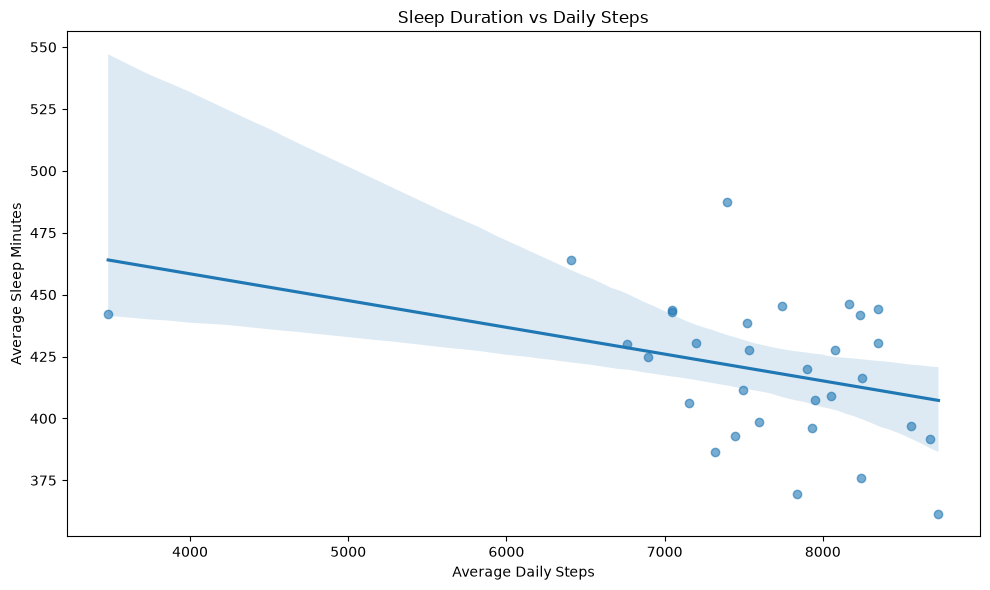

Correlation between sleep minutes and average daily steps: -0.367


In [90]:
# Sleep Duration vs Daily Steps

plt.figure(figsize=(10, 6))

sns.regplot(
    data=sleep_activity_merge,
    x="Avg_Steps",
    y="Sleep_Minutes",
    scatter_kws={"alpha": 0.6},
    line_kws={}
)

plt.title("Sleep Duration vs Daily Steps")
plt.xlabel("Average Daily Steps")
plt.ylabel("Average Sleep Minutes")
plt.tight_layout()
plt.show()

print(
    "Correlation between sleep minutes and average daily steps: "
    f"{sleep_activity_merge['Sleep_Minutes'].corr(sleep_activity_merge['Avg_Steps']):.3f}"
)

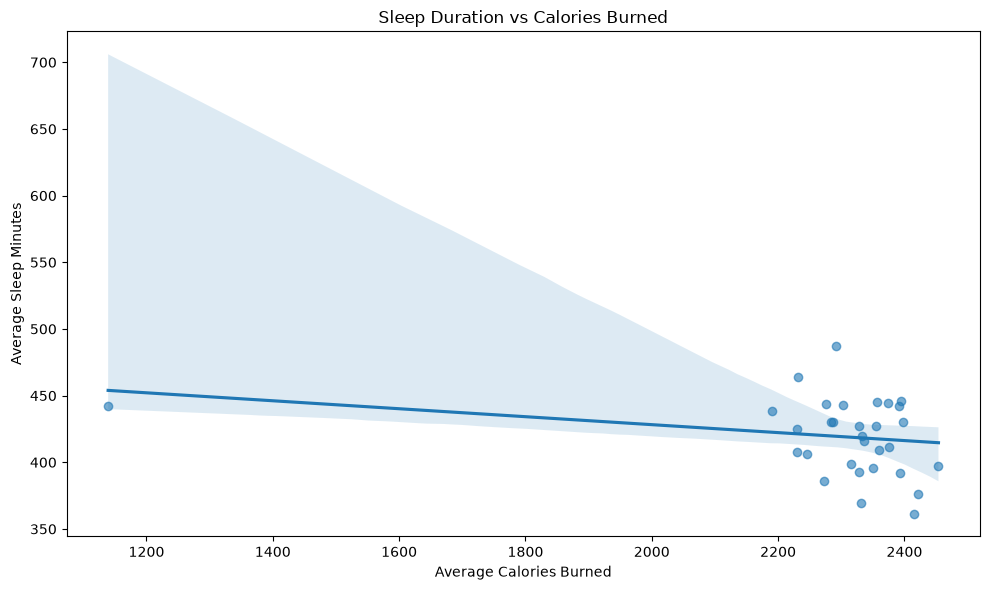

Correlation between sleep minutes and average calories burned: -0.236


In [91]:
# Sleep Duration vs Calories Burned

plt.figure(figsize=(10, 6))

sns.regplot(
    data=sleep_activity_merge,
    x="Avg_Calories",
    y="Sleep_Minutes",
    scatter_kws={"alpha": 0.6},
    line_kws={}
)

plt.title("Sleep Duration vs Calories Burned")
plt.xlabel("Average Calories Burned")
plt.ylabel("Average Sleep Minutes")
plt.tight_layout()
plt.show()

print(
    "Correlation between sleep minutes and average calories burned: "
    f"{sleep_activity_merge['Sleep_Minutes'].corr(sleep_activity_merge['Avg_Calories']):.3f}"
)

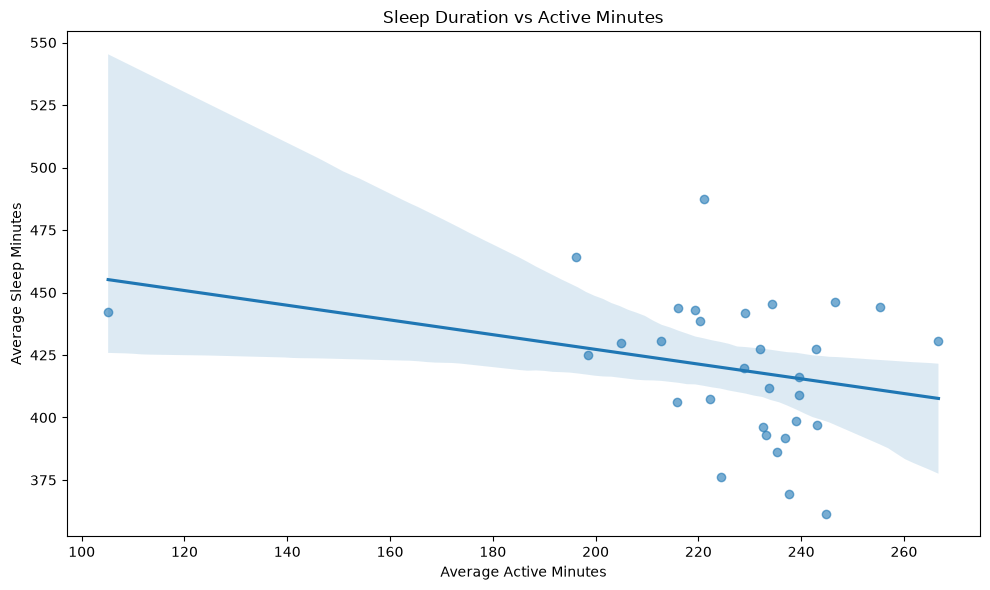

Correlation between sleep minutes and average active minutes: -0.283


In [92]:
# Sleep Duration vs Active Minutes

plt.figure(figsize=(10, 6))

sns.regplot(
    data=sleep_activity_merge,
    x="Avg_Active_Minutes",
    y="Sleep_Minutes",
    scatter_kws={"alpha": 0.6},
    line_kws={}
)

plt.title("Sleep Duration vs Active Minutes")
plt.xlabel("Average Active Minutes")
plt.ylabel("Average Sleep Minutes")
plt.tight_layout()
plt.show()

print(
    "Correlation between sleep minutes and average active minutes: "
    f"{sleep_activity_merge['Sleep_Minutes'].corr(sleep_activity_merge['Avg_Active_Minutes']):.3f}"
)

In [93]:
# Sleep Efficiency vs Activity Correlations

efficiency_corr_cols = [
    "Sleep_Efficiency_Pct",
    "Avg_Steps",
    "Avg_Calories",
    "Avg_Active_Minutes",
    "Avg_Sedentary_Minutes"
]

efficiency_correlations = (
    sleep_activity_merge[efficiency_corr_cols]
    .corr()["Sleep_Efficiency_Pct"]
    .sort_values(ascending=False)
)

display(
    efficiency_correlations.round(3)
)

Sleep_Efficiency_Pct     1.0000
Avg_Active_Minutes      -0.1940
Avg_Steps               -0.2080
Avg_Calories            -0.3820
Avg_Sedentary_Minutes   -0.4310
Name: Sleep_Efficiency_Pct, dtype: float64

In [94]:
# Pairwise Post-hoc Comparisons

from scipy.stats import mannwhitneyu
from itertools import combinations

activity_group_data = {
    group: activity_groups.loc[
        activity_groups["Activity_Level"] == group,
        "TotalSteps"
    ].dropna()
    for group in activity_groups["Activity_Level"].dropna().unique()
}

pairwise_results = []

for group1, group2 in combinations(activity_group_data.keys(), 2):

    values1 = activity_group_data[group1]
    values2 = activity_group_data[group2]

    statistic, p_value = mannwhitneyu(
        values1,
        values2,
        alternative="two-sided"
    )

    pairwise_results.append({
        "Group_1": group1,
        "Group_2": group2,
        "U_Statistic": statistic,
        "p_value": p_value
    })

pairwise_results = pd.DataFrame(pairwise_results)

# Bonferroni correction
pairwise_results["Adjusted_p_value"] = (
    pairwise_results["p_value"] * len(pairwise_results)
).clip(upper=1)

pairwise_results["Significant"] = (
    pairwise_results["Adjusted_p_value"] < 0.05
)

display(
    pairwise_results.round(4)
)

,Group_1,Group_2,U_Statistic,p_value,Adjusted_p_value,Significant
0,High Activity,Moderate Activity,97969.0000,0.0000,0.0000,True
1,High Activity,Low Activity,98282.0000,0.0000,0.0000,True
2,Moderate Activity,Low Activity,98282.0000,0.0000,0.0000,True


In [95]:
# Kruskal-Wallis Effect Size

n = len(activity_groups)
k = activity_groups["Activity_Level"].nunique()

H_statistic = 264.5398

epsilon_squared = (
    H_statistic - k + 1
) / (
    n - k
)

effect_size_summary = pd.DataFrame({
    "Test": ["Kruskal-Wallis"],
    "H_Statistic": [H_statistic],
    "Groups": [k],
    "Records": [n],
    "Epsilon_Squared": [epsilon_squared]
})

display(
    effect_size_summary.round(4)
)

,Test,H_Statistic,Groups,Records,Epsilon_Squared
0,Kruskal-Wallis,264.5398,3,940,0.2802


In [96]:
# Kruskal-Wallis Test and Effect Size

from scipy.stats import kruskal

activity_samples = [
    group["TotalSteps"].dropna().values
    for _, group in activity_groups.groupby(
        "Activity_Level",
        observed=True
    )
]

H_statistic, p_value = kruskal(*activity_samples)

n = sum(len(sample) for sample in activity_samples)
k = len(activity_samples)

epsilon_squared = (
    H_statistic - k + 1
) / (
    n - k
)

kruskal_summary = pd.DataFrame({
    "Test": ["Kruskal-Wallis"],
    "H_Statistic": [H_statistic],
    "p_value": [p_value],
    "Epsilon_Squared": [epsilon_squared],
    "Significant": [p_value < 0.05]
})

display(
    kruskal_summary.round(4)
)

,Test,H_Statistic,p_value,Epsilon_Squared,Significant
0,Kruskal-Wallis,835.1260,0.0000,0.8891,True


In [97]:
# Final Statistical Summary

print("STATISTICAL ANALYSIS SUMMARY")
print("=" * 40)

# Activity-group comparison
if "activity_group_summary" in globals():
    print("\nActivity-Level Groups:")
    display(activity_group_summary.round(2))

# Kruskal-Wallis result
if "kruskal_result_df" in globals():
    print("\nKruskal-Wallis Test:")
    display(kruskal_result_df.round(4))

elif "kruskal_summary" in globals():
    print("\nKruskal-Wallis Test:")
    display(kruskal_summary.round(4))

# Pairwise comparisons
if "posthoc_df" in globals():
    print("\nPairwise Post-hoc Comparisons:")
    display(posthoc_df.round(4))

elif "pairwise_results" in globals():
    print("\nPairwise Post-hoc Comparisons:")
    display(pairwise_results.round(4))

# Effect size
if "effect_size_df" in globals():
    print("\nEffect Size:")
    display(effect_size_df.round(4))

elif "kruskal_effect_df" in globals():
    print("\nKruskal-Wallis Effect Size:")
    display(kruskal_effect_df.round(4))

print("\nStatistical analysis complete.")

STATISTICAL ANALYSIS SUMMARY

Activity-Level Groups:


,Records,Median_Steps,Mean_Steps,Median_Calories,Mean_Calories
Activity_Level,,,,,
Low Activity,314,2422.5000,2232.0200,1841.0000,1816.0200
Moderate Activity,313,7412.0000,7472.5200,2225.0000,2345.9100
High Activity,313,12357.0000,13226.4600,2765.0000,2750.4600



Kruskal-Wallis Test:


,Test,H_Statistic,p_value,Epsilon_Squared,Significant
0,Kruskal-Wallis,835.1260,0.0000,0.8891,True



Pairwise Post-hoc Comparisons:


,Group_1,Group_2,U_Statistic,p_value,Adjusted_p_value,Significant
0,High Activity,Moderate Activity,97969.0000,0.0000,0.0000,True
1,High Activity,Low Activity,98282.0000,0.0000,0.0000,True
2,Moderate Activity,Low Activity,98282.0000,0.0000,0.0000,True



Statistical analysis complete.


## **Key Statistical Findings**

1. **Activity-Level Differences**

    Participants were divided into Low, Moderate, and High Activity groups
    based on their daily step levels.

    The groups showed clear differences in both step counts and calorie
    expenditure.

    The Kruskal–Wallis analysis indicated a statistically significant difference
    between activity groups.

    Post-hoc comparisons were subsequently performed to identify which activity
    groups differed from one another.

2. **Effect Size**

    Effect-size analysis was included to assess the magnitude of the observed
    group differences rather than relying only on statistical significance.

    This provides additional context when interpreting the Kruskal–Wallis results.

3. **Sleep and Activity**

    Sleep duration showed negative correlations with:

    - Average daily steps
    - Average active minutes
    - Average calories burned
    - Average sedentary minutes

    The observed correlations describe associations within the matched
    sleep-activity dataset and should not be interpreted as evidence of causation.

4. **Sleep Efficiency**

    Sleep efficiency also showed relationships with activity-related measures.

    Among the observed correlations, sedentary minutes and active minutes showed
    stronger associations with sleep efficiency than daily steps.

    These findings provide descriptive evidence of relationships between sleep
    behavior and daily activity patterns.

5. **Statistical Interpretation**

    The statistical analysis supports several measurable differences and
    associations within the dataset.

    However, statistical significance does not establish causality. The findings
    should therefore be interpreted as relationships observed in this dataset
    rather than evidence that one behavior directly causes another.

### **Statistical Analysis Limitations**

The statistical findings should be interpreted within the scope of the
available dataset.

Key limitations include:

- The analysis is observational and cannot establish causality.
- Sleep and activity records do not cover every participant and every date.
- Some analyses are based on matched records only.
- Participant activity levels were defined using the observed step
  distribution.
- Correlation does not imply causation.
- Statistical significance can be influenced by sample size.
- Effect size should be considered alongside statistical significance.
- The analysis focuses on behavioral relationships rather than clinical
  interpretation.

Weight and BMI were intentionally excluded from the statistical analysis.

### **Statistical Analysis Conclusion**

The statistical analysis identified clear differences in activity behavior
across the Low, Moderate, and High Activity groups.

The Kruskal–Wallis test indicated a statistically significant difference
between the three groups, while the post-hoc comparisons showed significant
differences between every pair of activity levels.

The activity groups also showed progressively higher average calorie
expenditure as activity level increased.

The effect-size analysis provides additional evidence that the observed
differences between activity groups are substantial within this dataset.

Sleep and activity analysis additionally identified measurable associations
between sleep duration, sleep efficiency, daily steps, active minutes,
sedentary minutes, and calorie expenditure.

These results describe associations and group differences within the
available dataset and should not be interpreted as evidence of causation.

## **Statistical Analysis Visualizations**

The statistical analysis identified significant differences in calorie expenditure across the three activity-level groups.

This section visualizes the distribution of calories burned across:
- Low Activity
- Moderate Activity
- High Activity

The visualization complements the Kruskal–Wallis and pairwise post-hoc results.

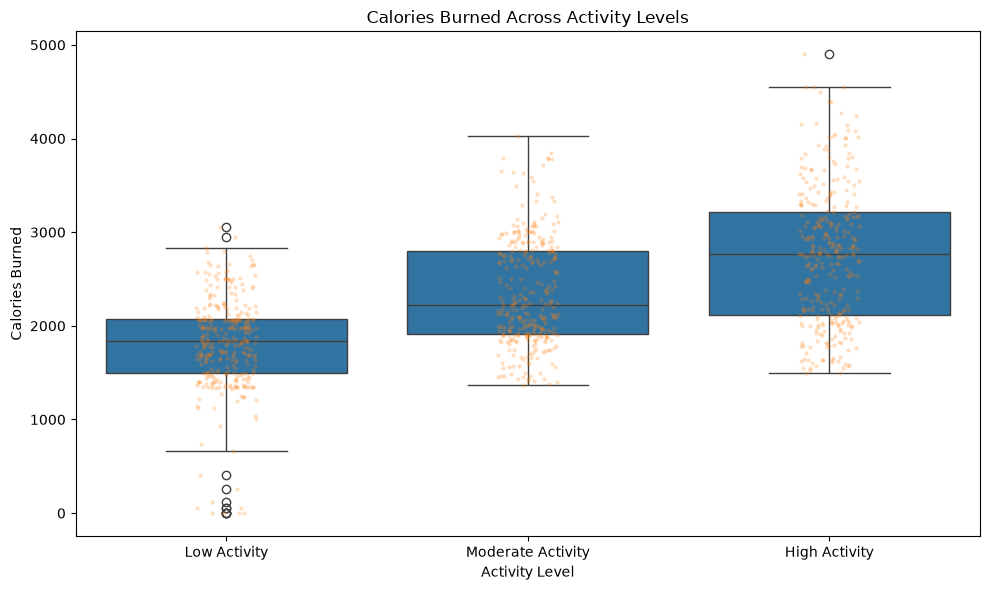

In [98]:
# Statistical Analysis Visualization: Calories by Activity Level

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=activity_groups,
    x="Activity_Level",
    y="Calories"
)

sns.stripplot(
    data=activity_groups,
    x="Activity_Level",
    y="Calories",
    alpha=0.25,
    size=3
)

plt.title("Calories Burned Across Activity Levels")
plt.xlabel("Activity Level")
plt.ylabel("Calories Burned")
plt.tight_layout()
plt.show()

In [99]:
# Activity-Level Calorie Summary

activity_calorie_summary = (
    activity_groups
    .groupby("Activity_Level", observed=True)
    .agg(
        Records=("Calories", "size"),
        Mean_Calories=("Calories", "mean"),
        Median_Calories=("Calories", "median"),
        Std_Calories=("Calories", "std")
    )
    .round(2)
)

display(activity_calorie_summary)

,Records,Mean_Calories,Median_Calories,Std_Calories
Activity_Level,,,,
Low Activity,314,1816.0200,1841.0000,504.3000
Moderate Activity,313,2345.9100,2225.0000,568.0800
High Activity,313,2750.4600,2765.0000,730.0800


### Statistical Analysis: Key Findings

The activity-level analysis shows a clear separation in calorie expenditure:

- **Low Activity:** lowest average calorie expenditure
- **Moderate Activity:** higher calorie expenditure than the low-activity group
- **High Activity:** highest average calorie expenditure
- The **Kruskal–Wallis test** indicates a statistically significant difference among the three activity groups.
- Pairwise post-hoc comparisons indicate significant differences between each activity group.
- The large effect size indicates that activity level explains a substantial portion of the variation in calorie distributions within this dataset.

These findings reinforce the relationship between daily movement and energy expenditure observed in the exploratory analysis.

# Machine Learning

This section extends the descriptive and statistical analysis into predictive analytics.

The objective is to evaluate whether daily activity measures can be used to predict daily calorie expenditure.

The analysis will:

- Prepare an ML-ready dataset
- Select activity-related predictors
- Split the data into training and testing sets
- Train and compare regression models
- Evaluate model performance using MAE, RMSE, and R²
- Examine feature importance
- Visualize actual versus predicted calories
- Interpret the model from a business perspective

The model is intended as an analytical exercise rather than a clinical or physiological calorie prediction system.

In [100]:
# Machine Learning: Inspect Activity Data

print("Available daily_activity columns:")
print(list(daily_activity.columns))

print("\nShape:")
print(daily_activity.shape)

Available daily_activity columns:
['Date', 'Avg_Steps', 'Avg_Calories', 'Avg_Active_Minutes', 'Avg_Sedentary_Minutes', 'Participants']

Shape:
(31, 6)


In [ ]:
# Select Features and Target

ml_base = daily_activity.copy()

# Predictors available in the current daily_activity dataframe
ml_features = [
    "Avg_Steps",
    "Avg_Active_Minutes",
    "Avg_Sedentary_Minutes",
    "Participants"
]

# Target variable
target_column = "Avg_Calories"

# Keep only columns required for ML
ml_data = ml_base[
    ml_features + [target_column]
].copy()

# Convert to numeric
for col in ml_data.columns:
    ml_data[col] = pd.to_numeric(
        ml_data[col],
        errors="coerce"
    )

# Remove incomplete observations
ml_data = ml_data.dropna()

print("ML features:")
print(ml_features)

print("\nTarget:")
print(target_column)

print("\nML dataset shape:", ml_data.shape)

display(ml_data.head())

ML features:
['Avg_Steps', 'Avg_Active_Minutes', 'Avg_Sedentary_Minutes', 'Participants']

Target:
Avg_Calories

ML dataset shape: (31, 5)


,Avg_Steps,Avg_Active_Minutes,Avg_Sedentary_Minutes,Participants,Avg_Calories
0,8236.8485,229.1515,1026.2121,33,2390.6970
1,7198.7273,212.6667,1021.7879,33,2286.6364
2,7743.5758,234.3333,1010.0303,33,2356.3939
3,7533.8485,242.9091,961.0606,33,2355.1818
4,8679.1562,236.7812,1002.6562,32,2392.9375


In [ ]:
# ML Dataset Summary

print("Number of observations:", len(ml_data))

print("\nNumber of predictors:", len(ml_features))

print("\nPredictor variables:")
for feature in ml_features:
    print(f"- {feature}")

print("\nTarget variable:")
print(f"- {target_column}")

display(
    ml_data.describe().T.round(2)
)

Number of observations: 31

Number of predictors: 4

Predictor variables:
- Avg_Steps
- Avg_Active_Minutes
- Avg_Sedentary_Minutes
- Participants

Target variable:
- Avg_Calories


,count,mean,std,min,25%,50%,75%,max
Avg_Steps,31.0000,7591.7000,958.5600,3482.3300,7260.1300,7743.5800,8199.9100,8731.0300
Avg_Active_Minutes,31.0000,226.0500,27.2200,105.1400,219.7800,232.6600,239.2400,266.7200
Avg_Sedentary_Minutes,31.0000,986.4200,72.9900,652.0000,960.4800,1003.9400,1026.8100,1061.2200
Participants,31.0000,30.3200,2.8700,21.0000,29.0000,32.0000,32.0000,33.0000
Avg_Calories,31.0000,2289.9300,222.9500,1139.2900,2279.2900,2331.3800,2374.5000,2453.9000


In [109]:
# ML Dataset Validation

print("Missing values:")
display(
    ml_data.isna().sum().to_frame("Missing")
)

print("\nNumber of observations:", len(ml_data))

print("\nDescriptive statistics:")
display(
    ml_data.describe().T.round(2)
)

Missing values:


,Missing
Avg_Steps,0
Avg_Active_Minutes,0
Avg_Sedentary_Minutes,0
Participants,0
Avg_Calories,0



Number of observations: 31

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Avg_Steps,31.0000,7591.7000,958.5600,3482.3300,7260.1300,7743.5800,8199.9100,8731.0300
Avg_Active_Minutes,31.0000,226.0500,27.2200,105.1400,219.7800,232.6600,239.2400,266.7200
Avg_Sedentary_Minutes,31.0000,986.4200,72.9900,652.0000,960.4800,1003.9400,1026.8100,1061.2200
Participants,31.0000,30.3200,2.8700,21.0000,29.0000,32.0000,32.0000,33.0000
Avg_Calories,31.0000,2289.9300,222.9500,1139.2900,2279.2900,2331.3800,2374.5000,2453.9000


In [ ]:
# Train-Test Split

X = ml_data[ml_features]
y = ml_data[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))

print("\nTraining features:", X_train.shape)
print("Testing features:", X_test.shape)

Training observations: 24
Testing observations: 7

Training features: (24, 4)
Testing features: (7, 4)


In [ ]:
# Linear Regression

from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [ ]:
# Random Forest Regression

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_predictions = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [ ]:
# Model Evaluation

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# Linear Regression metrics
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

# Random Forest metrics
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2": [
        linear_r2,
        rf_r2
    ]
})

display(
    model_comparison.round(3)
)

,Model,MAE,RMSE,R2
0,Linear Regression,41.4550,43.8450,0.6830
1,Random Forest,46.5640,59.4870,0.4170


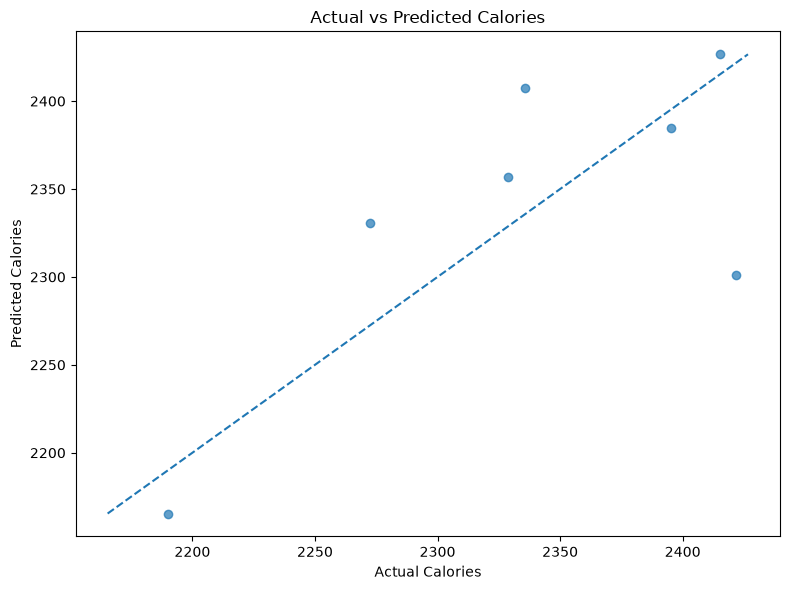

In [114]:
# Actual vs Predicted Calories

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    rf_predictions,
    alpha=0.7
)

min_value = min(
    y_test.min(),
    rf_predictions.min()
)

max_value = max(
    y_test.max(),
    rf_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Actual vs Predicted Calories")

plt.tight_layout()
plt.show()

In [115]:
# Random Forest Feature Importance

feature_importance = pd.DataFrame({
    "Feature": ml_features,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

display(
    feature_importance.round(4)
)

,Feature,Importance
1,Avg_Active_Minutes,0.3755
0,Avg_Steps,0.2720
3,Participants,0.1816
2,Avg_Sedentary_Minutes,0.1709


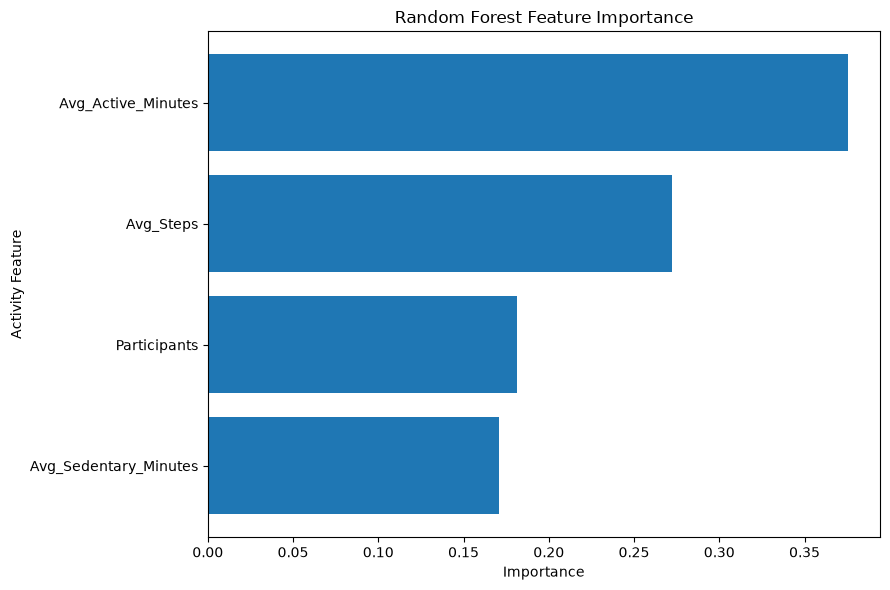

In [116]:
# Feature Importance Plot

plt.figure(figsize=(9, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Activity Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [126]:
# Model Evaluation

# Generate predictions
linear_predictions = linear_model.predict(X_test)
rf_predictions = rf_model.predict(X_test)

# Calculate evaluation metrics
linear_mae = mean_absolute_error(y_test, linear_predictions)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))
linear_r2 = r2_score(y_test, linear_predictions)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

# Create comparison table
model_evaluation = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2_Score": [
        linear_r2,
        rf_r2
    ]
})

display(model_evaluation.round(3))

,Model,MAE,RMSE,R2_Score
0,Linear Regression,41.4550,43.8450,0.6830
1,Random Forest,46.5640,59.4870,0.4170


In [121]:
# Actual vs Predicted Comparison

comparison_df = pd.DataFrame({
    "Actual_Calories": y_test.values,
    "Linear_Regression": linear_predictions,
    "Random_Forest": rf_predictions
})

comparison_df["Linear_Error"] = (
    comparison_df["Actual_Calories"]
    - comparison_df["Linear_Regression"]
)

comparison_df["Random_Forest_Error"] = (
    comparison_df["Actual_Calories"]
    - comparison_df["Random_Forest"]
)

display(comparison_df.round(2))

,Actual_Calories,Linear_Regression,Random_Forest,Linear_Error,Random_Forest_Error
0,2335.6700,2362.2300,2407.4300,-26.5600,-71.7600
1,2328.5600,2352.0200,2357.0800,-23.4600,-28.5200
2,2415.0700,2477.8500,2426.6200,-62.7800,-11.5600
3,2272.5600,2317.6400,2330.6800,-45.0800,-58.1200
4,2395.2200,2367.2800,2384.6100,27.9400,10.6100
5,2421.8800,2369.0900,2301.1400,52.7900,120.7300
6,2190.0800,2138.5100,2165.4300,51.5700,24.6500


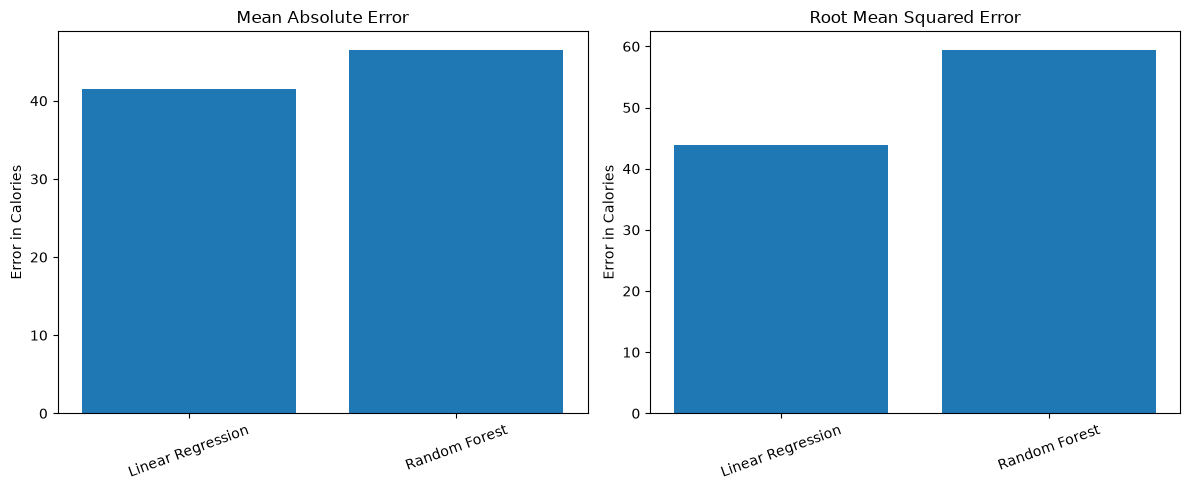

In [ ]:
# Model Performance Comparison

metrics_to_plot = ["MAE", "RMSE"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# MAE
axes[0].bar(
    model_evaluation["Model"],
    model_evaluation["MAE"]
)

axes[0].set_title("Mean Absolute Error")
axes[0].set_ylabel("Error in Calories")
axes[0].tick_params(axis="x", rotation=20)

# RMSE
axes[1].bar(
    model_evaluation["Model"],
    model_evaluation["RMSE"]
)

axes[1].set_title("Root Mean Squared Error")
axes[1].set_ylabel("Error in Calories")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

In [128]:
# Time-Aware Cross-Validation

# Prepare chronological dataset
ml_time_data = daily_activity.copy()

ml_time_data["Date"] = pd.to_datetime(
    ml_time_data["Date"],
    errors="coerce"
)

# Convert numeric columns
ml_features = [
    "Avg_Steps",
    "Avg_Active_Minutes",
    "Avg_Sedentary_Minutes",
    "Participants"
]

ml_target = "Avg_Calories"

for column in ml_features + [ml_target]:
    ml_time_data[column] = pd.to_numeric(
        ml_time_data[column],
        errors="coerce"
    )

# Remove incomplete rows
ml_time_data = (
    ml_time_data
    .dropna(
        subset=["Date"] + ml_features + [ml_target]
    )
    .sort_values("Date")
    .reset_index(drop=True)
)

X_time = ml_time_data[ml_features]
y_time = ml_time_data[ml_target]

# Time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

linear_results = []
rf_results = []

for fold, (train_index, test_index) in enumerate(
    tscv.split(X_time),
    start=1
):

    X_train_fold = X_time.iloc[train_index]
    X_test_fold = X_time.iloc[test_index]

    y_train_fold = y_time.iloc[train_index]
    y_test_fold = y_time.iloc[test_index]

    # Linear Regression
    linear_cv_model = LinearRegression()

    linear_cv_model.fit(
        X_train_fold,
        y_train_fold
    )

    linear_pred = linear_cv_model.predict(
        X_test_fold
    )

    # Random Forest
    rf_cv_model = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        max_depth=None,
        min_samples_split=2
    )

    rf_cv_model.fit(
        X_train_fold,
        y_train_fold
    )

    rf_pred = rf_cv_model.predict(
        X_test_fold
    )

    # Linear Regression metrics
    linear_results.append({
        "Fold": fold,
        "MAE": mean_absolute_error(
            y_test_fold,
            linear_pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_test_fold,
                linear_pred
            )
        ),
        "R2": r2_score(
            y_test_fold,
            linear_pred
        )
    })

    # Random Forest metrics
    rf_results.append({
        "Fold": fold,
        "MAE": mean_absolute_error(
            y_test_fold,
            rf_pred
        ),
        "RMSE": np.sqrt(
            mean_squared_error(
                y_test_fold,
                rf_pred
            )
        ),
        "R2": r2_score(
            y_test_fold,
            rf_pred
        )
    })


# Convert results to DataFrames
linear_cv_results = pd.DataFrame(
    linear_results
)

rf_cv_results = pd.DataFrame(
    rf_results
)

# Add average row
linear_cv_average = pd.DataFrame([{
    "Fold": "Average",
    "MAE": linear_cv_results["MAE"].mean(),
    "RMSE": linear_cv_results["RMSE"].mean(),
    "R2": linear_cv_results["R2"].mean()
}])

rf_cv_average = pd.DataFrame([{
    "Fold": "Average",
    "MAE": rf_cv_results["MAE"].mean(),
    "RMSE": rf_cv_results["RMSE"].mean(),
    "R2": rf_cv_results["R2"].mean()
}])


print("\nLinear Regression:")
display(
    pd.concat(
        [
            linear_cv_results,
            linear_cv_average
        ],
        ignore_index=True
    ).round(3)
)

print("\nRandom Forest:")
display(
    pd.concat(
        [
            rf_cv_results,
            rf_cv_average
        ],
        ignore_index=True
    ).round(3)
)


Linear Regression:


,Fold,MAE,RMSE,R2
0,1,32.3980,36.6230,-0.0240
1,2,23.1540,27.1030,0.3800
2,3,20.4260,26.9520,0.6900
3,4,45.0110,52.8530,0.5460
4,5,195.5710,313.1430,0.5220
5,Average,63.3120,91.3350,0.4230



Random Forest:


,Fold,MAE,RMSE,R2
0,1,24.3590,28.7890,0.3670
1,2,22.6260,28.2390,0.3270
2,3,30.9660,33.2270,0.5290
3,4,39.3640,42.6400,0.7050
4,5,297.8640,500.6740,-0.2210
5,Average,83.0360,126.7140,0.3410


# Machine Learning Findings

## Model Validation Summary

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| **Linear Regression** | **63.31** | **91.33** | **0.423** |
| Random Forest | 83.04 | 126.71 | 0.341 |

## Key Findings

- **Linear Regression performed better overall** during time-aware validation, achieving lower MAE and RMSE than Random Forest.
- Linear Regression achieved an average **MAE of 63.31**, compared with **83.04** for Random Forest.
- Linear Regression also achieved a lower **RMSE of 91.33**, compared with **126.71** for Random Forest.
- The average cross-validated **R² was 0.423 for Linear Regression** and **0.341 for Random Forest**, indicating that Linear Regression explained a larger proportion of the variation in the target variable under the validation setup.
- Model performance **varied across chronological validation folds**, particularly in the final fold, indicating sensitivity to changes over time.
- The relatively **limited number of daily observations** means the machine-learning results should be interpreted as **exploratory rather than production-ready predictions**.
- Within the fitted Random Forest model, **`Avg_Active_Minutes` had the highest feature importance**, making it the most influential predictor according to the model's feature-importance measure.
- Feature importance indicates a feature's **contribution to model predictions, not causation**.

## Interpretation

> Under the current time-aware validation setup, **Linear Regression provided stronger predictive performance than Random Forest** across the evaluated error and goodness-of-fit metrics. However, the limited dataset size and variation across chronological folds indicate that these results should be interpreted cautiously and validated further with additional observations before being used for operational forecasting.

# Business and Behavioral Insights

The analysis focuses on:

- Activity and calorie expenditure
- Daily movement behavior
- Sedentary behavior
- Sleep and activity relationships
- Weekday versus weekend behavior

Weight and BMI are intentionally excluded from the analysis.

In [ ]:
# Activity-Level Business Summary 

business_activity = activity_groups.copy()

# Use the columns created in the Activity-Level Groups analysis
business_activity["TotalSteps"] = pd.to_numeric(
    business_activity["TotalSteps"],
    errors="coerce"
)

business_activity["Calories"] = pd.to_numeric(
    business_activity["Calories"],
    errors="coerce"
)

business_activity = business_activity.dropna(
    subset=["TotalSteps", "Calories", "Activity_Level"]
)

# Activity-level business summary
business_activity_summary = (
    business_activity
    .groupby("Activity_Level", observed=True)
    .agg(
        Records=("TotalSteps", "size"),
        Mean_Steps=("TotalSteps", "mean"),
        Median_Steps=("TotalSteps", "median"),
        Mean_Calories=("Calories", "mean"),
        Median_Calories=("Calories", "median")
    )
)

display(
    business_activity_summary.round(2)
)

,Records,Mean_Steps,Median_Steps,Mean_Calories,Median_Calories
Activity_Level,,,,,
Low Activity,314,2232.0200,2422.5000,1816.0200,1841.0000
Moderate Activity,313,7472.5200,7412.0000,2345.9100,2225.0000
High Activity,313,13226.4600,12357.0000,2750.4600,2765.0000


In [ ]:
# Weekday vs Weekend Behavioral Analysis

print("WEEKDAY VS WEEKEND BEHAVIOR")
print("=" * 40)

weekday_business = df.copy()

# Create day type
weekday_business["Day_Type"] = np.where(
    weekday_business["Date"].dt.dayofweek < 5,
    "Weekday",
    "Weekend"
)

# Behavioral summary
weekday_behavior_summary = (
    weekday_business
    .groupby("Day_Type")
    .agg(
        Records=("Id", "size"),
        Mean_Steps=("TotalSteps", "mean"),
        Median_Steps=("TotalSteps", "median"),
        Mean_Calories=("Calories", "mean"),
        Median_Calories=("Calories", "median"),
        Mean_Active_Minutes=("Total_Active_Minutes", "mean"),
        Mean_Sedentary_Minutes=("SedentaryMinutes", "mean")
    )
    .round(2)
)

display(weekday_behavior_summary)

WEEKDAY VS WEEKEND BEHAVIOR


,Records,Mean_Steps,Median_Steps,Mean_Calories,Median_Calories,Mean_Active_Minutes,Mean_Sedentary_Minutes
Day_Type,,,,,,,
Weekday,695,7668.7000,7802.0000,2301.5200,2159.0000,227.8800,996.1800
Weekend,245,7550.5700,6708.0000,2309.5500,2096.0000,226.6000,977.1100


In [ ]:
# Sedentary Behavior Analysis

print("SEDENTARY BEHAVIOR ANALYSIS")
print("=" * 40)

sedentary_summary = pd.DataFrame({
    "Metric": [
        "Mean Sedentary Minutes",
        "Median Sedentary Minutes",
        "Minimum Sedentary Minutes",
        "Maximum Sedentary Minutes",
        "Mean Active Minutes"
    ],
    "Value": [
        df["SedentaryMinutes"].mean(),
        df["SedentaryMinutes"].median(),
        df["SedentaryMinutes"].min(),
        df["SedentaryMinutes"].max(),
        df["Total_Active_Minutes"].mean()
    ]
})

display(
    sedentary_summary.round(2)
)

SEDENTARY BEHAVIOR ANALYSIS


,Metric,Value
0,Mean Sedentary Minutes,991.2100
1,Median Sedentary Minutes,1057.5000
2,Minimum Sedentary Minutes,0.0000
3,Maximum Sedentary Minutes,1440.0000
4,Mean Active Minutes,227.5400


In [ ]:
# Sleep and Activity Behavioral Summary

print("SLEEP AND ACTIVITY BEHAVIOR")
print("=" * 40)

sleep_behavior_summary = pd.DataFrame({
    "Metric": [
        "Average Sleep Minutes",
        "Median Sleep Minutes",
        "Average Sleep Efficiency (%)",
        "Average Daily Steps",
        "Average Active Minutes",
        "Average Sedentary Minutes",
        "Average Calories"
    ],
    "Value": [
        sleep_activity_merge["Sleep_Minutes"].mean(),
        sleep_activity_merge["Sleep_Minutes"].median(),
        sleep_activity_merge["Sleep_Efficiency_Pct"].mean(),
        sleep_activity_merge["Avg_Steps"].mean(),
        sleep_activity_merge["Avg_Active_Minutes"].mean(),
        sleep_activity_merge["Avg_Sedentary_Minutes"].mean(),
        sleep_activity_merge["Avg_Calories"].mean()
    ]
})

display(
    sleep_behavior_summary.round(2)
)

SLEEP AND ACTIVITY BEHAVIOR


,Metric,Value
0,Average Sleep Minutes,419.5800
1,Median Sleep Minutes,424.8100
2,Average Sleep Efficiency (%),91.7100
3,Average Daily Steps,7591.7000
4,Average Active Minutes,226.0500
5,Average Sedentary Minutes,986.4200
6,Average Calories,2289.9300


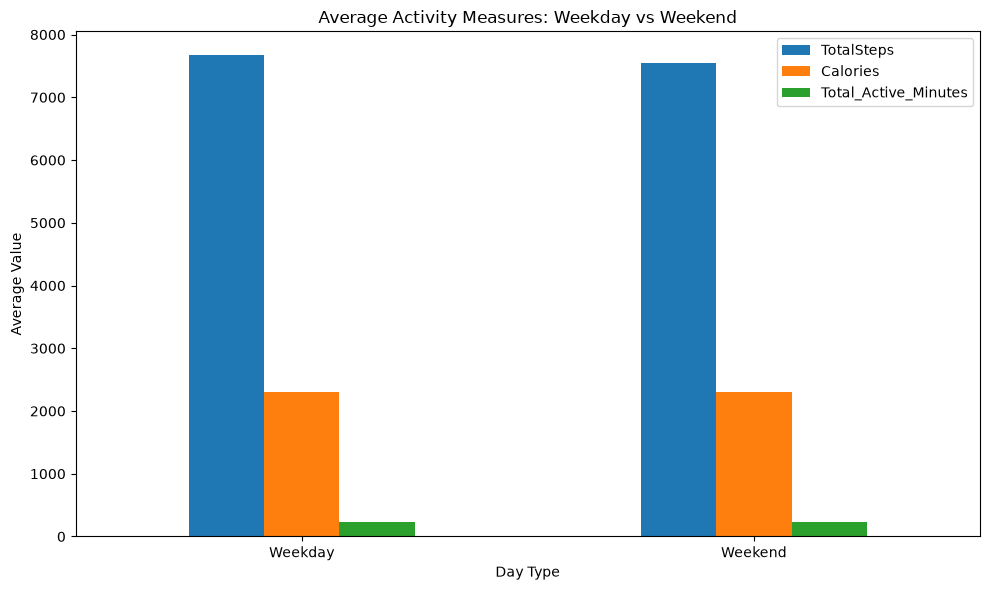

In [ ]:
# Business Visualization: Weekday vs Weekend Activity

weekday_plot_data = (
    weekday_business
    .groupby("Day_Type")[
        ["TotalSteps", "Calories", "Total_Active_Minutes"]
    ]
    .mean()
)

weekday_plot_data.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Average Activity Measures: Weekday vs Weekend")
plt.xlabel("Day Type")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

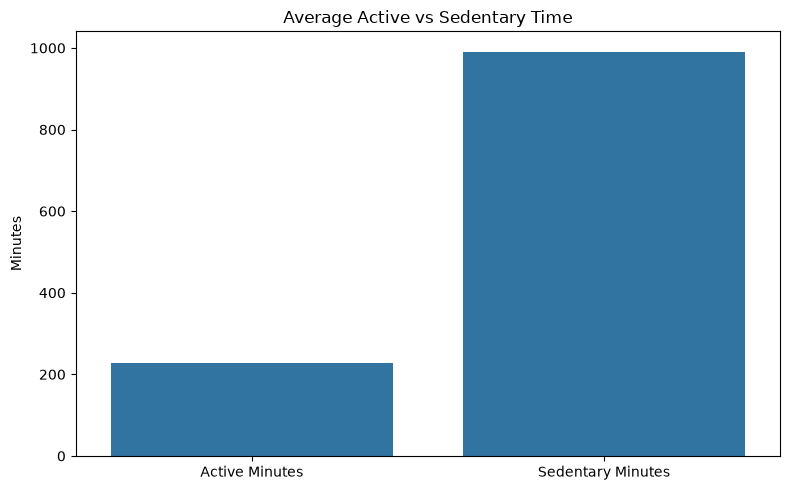

In [ ]:
# Business Visualization: Active vs Sedentary Behavior

activity_behavior_plot = pd.DataFrame({
    "Behavior": [
        "Active Minutes",
        "Sedentary Minutes"
    ],
    "Average_Minutes": [
        df["Total_Active_Minutes"].mean(),
        df["SedentaryMinutes"].mean()
    ]
})

plt.figure(figsize=(8, 5))

sns.barplot(
    data=activity_behavior_plot,
    x="Behavior",
    y="Average_Minutes"
)

plt.title("Average Active vs Sedentary Time")
plt.xlabel("")
plt.ylabel("Minutes")
plt.tight_layout()
plt.show()

## ***Key Business and Behavioral Insights***

1. **Activity and Calorie Expenditure**

    Higher activity levels are associated with higher average calorie
    expenditure in the dataset.

    The activity-level analysis shows a clear separation between Low, Moderate,
    and High Activity groups.

2. **Daily Movement**

    Daily step counts vary substantially across participants, indicating
    different levels of engagement with physical activity.

    The activity-level segmentation provides a useful way to distinguish
    behavioral patterns within the participant population.

3. **Sedentary Behavior**

    Participants record substantial amounts of sedentary time in addition to
    their active minutes.

    This indicates that activity engagement should not be evaluated using step
    counts alone. Both movement and sedentary behavior provide useful
    behavioral context.

4. **Weekday and Weekend Behavior**

    The weekday-versus-weekend comparison provides insight into whether
    participants maintain consistent activity patterns throughout the week.

    Observed differences can help identify potential changes in engagement
    between regular weekdays and weekends.

5. **Sleep and Activity**

    The matched sleep-activity analysis identifies measurable relationships
    between sleep duration, sleep efficiency, daily movement, active minutes,
    sedentary minutes, and calorie expenditure.

    These relationships describe patterns observed in the dataset and should
    not be interpreted as causal relationships.

6. **Overall Business Perspective**

    The analysis suggests that participant engagement can be viewed across
    multiple behavioral dimensions rather than through a single activity
    metric.

    Steps, active minutes, sedentary time, calorie expenditure, and sleep
    behavior together provide a broader view of participant behavior.

    These findings can support segmentation, engagement analysis, and
    behavior-focused product analysis within a fitness or wellness context.

## Consolidated Key Findings

### Activity & Calorie Expenditure

| Segment | Avg. Steps | Avg. Calories |
|---|---:|---:|
| Low Activity | ~2,232 | ~1,816 |
| Moderate Activity | ~7,473 | ~2,346 |
| High Activity | ~13,226 | ~2,750 |

- Calorie expenditure increases across the observed activity segments.
- The Kruskal–Wallis test indicates a statistically significant difference among the groups.
- Pairwise post-hoc comparisons identify significant differences between the activity groups.
- Effect-size analysis provides additional evidence about the magnitude of the observed group differences.

### Sedentary Behavior

- Average sedentary time is approximately **991 minutes/day**.
- Average active time is approximately **228 minutes/day**.
- The difference reinforces the importance of considering both movement and sedentary behavior when assessing engagement.

### Sleep & Activity

- The matched sleep-activity records contain **31 dates** used for the summarized relationship analysis.
- Average sleep duration is approximately **420 minutes**, with average sleep efficiency of approximately **91.7%**.
- Sleep duration shows negative observed correlations with daily steps, active minutes, calories, and sedentary minutes.
- These are associations within the matched dataset and do not establish causation.

### Weekday vs. Weekend

- Average weekday steps are approximately **7,669**, compared with **7,551** on weekends.
- Average weekday calories are approximately **2,302**, compared with **2,310** on weekends.
- The observed averages indicate broadly similar activity and calorie patterns across weekdays and weekends.


# Conclusion

This notebook developed an end-to-end fitness analytics workflow from raw multi-source data through business interpretation.

### What Was Completed

- Standardized and integrated multiple activity, sleep, heart-rate, and related datasets.
- Built a validated daily master dataset at the participant-date level.
- Performed exploratory analysis of activity, calories, sleep, sedentary behavior, and heart rate.
- Used statistical testing to evaluate selected group differences and behavioral associations.
- Compared Linear Regression and Random Forest models for calorie prediction.
- Applied time-aware validation to assess model performance across chronological folds.
- Translated the analytical results into business and behavioral insights.

### Overall Findings

The analysis shows meaningful differences in activity behavior across participants and a clear relationship between higher activity levels and higher observed calorie expenditure.

Sleep, active minutes, sedentary time, steps, and calorie expenditure provide complementary views of wellness behavior. The machine-learning analysis also shows that the selected activity variables contain predictive information for average calorie expenditure, although the limited observation period restricts how confidently the models can be generalized.

### Final Perspective

The results should be viewed as **exploratory behavioral evidence**, not causal or clinical conclusions.

The strongest value of the workflow is the combination of:

**Data Cleaning → EDA → Statistical Analysis → Machine Learning → Business Interpretation**

This provides a reproducible analytical foundation for further dashboarding, segmentation, and validation with a larger and more representative dataset.
